# Player Impact

## Research Question  
> How much does a single player contribute to the overall success of their team?

In this notebook, we investigate individual player impact in the NBA based on detailed performance data from the regular season. The analysis starts with the dataset `player_statistics_regular_season.csv`, which provides an initial view into the topic and is used specifically for time-normalized metrics (e.g., per-minute statistics). This serves as a foundation for exploring key performance indicators and understanding basic patterns in player data.

For the main analytical part of this project, particularly the normalization of performance metrics per possession, we rely on the more comprehensive dataset `player_statistics_v2.csv`. This updated dataset covers a shorter time span than the original one but includes many games that were previously untracked or incompletely recorded, thereby improving data quality and completeness for individual player analysis.

We apply various statistical methods and visualizations to:
- Identify high-impact players based on performance indicators
- Explore correlations between individual stats and team success
- Investigate whether standout individual performance translates into team victories

This analysis aims to generate meaningful insights about player contributions beyond traditional box score metrics and can support use cases such as scouting, strategic roster decisions, or data-driven salary evaluation.

---

Datasets  
- `player_statistics_regular_season.csv`: Used for early exploration and time-normalized (per-minute) metrics  
- `player_statistics_v2.csv`: Main dataset for in-depth analysis

## Setup

In [249]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import yaml
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [250]:
# load yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)
    DATA_PATH = config.get("data_path")
    if DATA_PATH is None:
        print("ERROR: No data path provided")
    USE_DRIVE = bool(config.get("use_drive", False))

In [251]:
# load from drive if requested
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

In [252]:
# Load the data
player_statistics = pd.read_csv(os.path.join(DATA_PATH, "player_statistics_regular_season.csv"),
                                low_memory=False)

print("Detailed column overview\n")

for col in player_statistics.columns:
    dtype = player_statistics[col].dtype
    missing = player_statistics[col].isnull().sum()

    if dtype == 'object':
        example_values = player_statistics[col].dropna().unique()[:3]
        examples = f"Examples: {str(list(example_values))}"
        print(f"| {str(col):<30} | {str(dtype):>15} | {examples:<80} | Missing: {missing:>10} |")
    else:
        min_val = player_statistics[col].min()
        max_val = player_statistics[col].max()
        r = f"Range: {min_val} to {max_val}"
        print(f"| {str(col):<30} | {str(dtype):>15} | {r:<80} | Missing: {missing:>10} |")


Detailed column overview

| firstName                      |          object | Examples: ['Kevin', 'Torrey', 'Al']                                              | Missing:          0 |
| lastName                       |          object | Examples: ['Durant', 'Craig', 'Horford']                                         | Missing:          0 |
| personId                       |           int64 | Range: 2 to 1642530                                                              | Missing:          0 |
| gameId                         |           int64 | Range: 20000001 to 29901189                                                      | Missing:          0 |
| gameDate                       |          object | Examples: ['2025-03-26 22:00:00', '2025-03-26 21:00:00', '2025-03-26 19:30:00']  | Missing:          0 |
| playerteamCity                 |          object | Examples: ['Phoenix', 'Boston', 'Denver']                                        | Missing:          0 |
| playerteamName          

## Key Variables for Player Impact Analysis

To assess how individual players contribute to their team's success, we focus on a set of core variables that reflect performance, efficiency, contextual factors, and direct impact on game outcomes.

| Category       | Key Columns                                                                 | Relevance for Player Impact                                                 |
|----------------|------------------------------------------------------------------------------|------------------------------------------------------------------------------|
| Performance | `points`, `assists`, `reboundsTotal`, `steals`, `blocks`, `turnovers`, `foulsPersonal` | Core in-game actions that reflect a player's visible contribution           |
| Efficiency  | `fieldGoalsPercentage`, `threePointersPercentage`, `freeThrowsPercentage`   | Shooting efficiency helps distinguish quality over quantity                 |
| On-Court Impact | `plusMinusPoints`                                                       | Measures how the team performs while the player is on the court             |
| Playing Time | `numMinutes`                                                               | Important to contextualize performance and normalize contributions          |
| Game Context | `home`, `win`, `playerteamName`, `opponentteamName`                       | Adds context regarding game location and opponent strength                  |

These variables form the foundation for evaluating player impact using descriptive statistics, correlation analysis, and potentially composite scoring metrics.


# Performance Indicators

# Normalisation per Minute

### Points per Minute and Assists per Minute

To fairly evaluate player performance regardless of playing time, we calculate per-minute metrics. Two intuitive and widely used indicators are:

- **Points per Minute (PPM):** Measures a player's scoring output relative to the time they spent on the court. This allows us to identify highly efficient scorers who may not play full games.
  
- **Assists per Minute (APM):** Reflects a player's ability to create scoring opportunities for teammates. It is particularly useful for evaluating playmakers and guards.

Both metrics help normalize raw performance and reveal impact that may not be visible through totals alone.

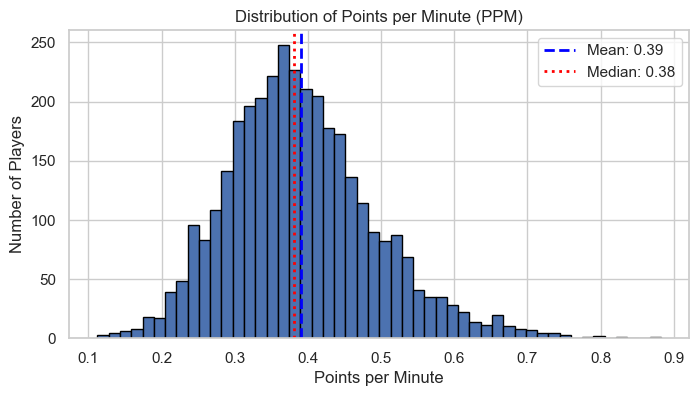

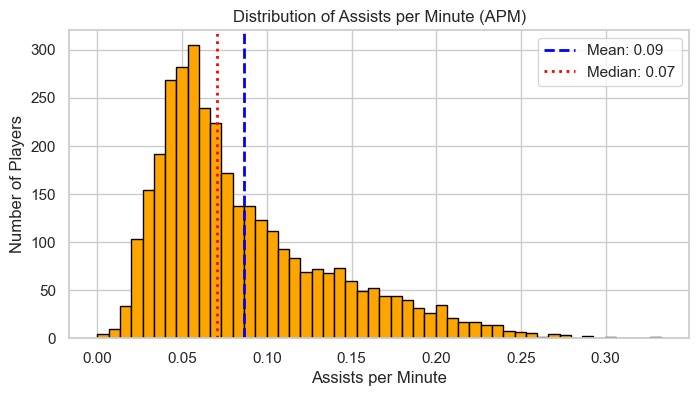

In [253]:
# Group by personId + full name and aggregate relevant metrics
player_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'points': 'sum',
        'assists': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'  # Number of games played
    })
    .rename(columns={'gameId': 'numGames'})
)

# Avoid division by zero: replace 0 minutes with NaN
player_summary['numMinutes'] = player_summary['numMinutes'].replace(0, np.nan)

# Calculate Points per Minute (PPM) and Assists per Minute (APM)
player_summary['points_per_minute'] = player_summary['points'] / player_summary['numMinutes']
player_summary['assists_per_minute'] = player_summary['assists'] / player_summary['numMinutes']

# Filter: Keep only players with at least 20 games and 200 minutes played
filtered_players = player_summary[
    (player_summary['numGames'] >= 20) &
    (player_summary['numMinutes'] >= 200)
]

# Compute stats
ppm_mean = filtered_players['points_per_minute'].mean()
ppm_median = filtered_players['points_per_minute'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_players['points_per_minute'].dropna(), bins=50, edgecolor='black')
plt.axvline(ppm_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {ppm_mean:.2f}')
plt.axvline(ppm_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {ppm_median:.2f}')
plt.title('Distribution of Points per Minute (PPM)')
plt.xlabel('Points per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

# Compute stats
apm_mean = filtered_players['assists_per_minute'].mean()
apm_median = filtered_players['assists_per_minute'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_players['assists_per_minute'].dropna(), bins=50, edgecolor='black', color='orange')
plt.axvline(apm_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {apm_mean:.2f}')
plt.axvline(apm_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {apm_median:.2f}')
plt.title('Distribution of Assists per Minute (APM)')
plt.xlabel('Assists per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

In [254]:
# Top 10 by Points per Minute
top10_ppm = (
    filtered_players
    .sort_values(by='points_per_minute', ascending=False)
    .head(10)
)

print("Top 10 Players by Points per Minute (PPM):")
display(top10_ppm[['firstName', 'lastName', 'numGames', 'numMinutes', 'points_per_minute']])

# Top 10 by Assists per Minute
top10_apm = (
    filtered_players
    .sort_values(by='assists_per_minute', ascending=False)
    .head(10)
)

print("Top 10 Players by Assists per Minute (APM):")
display(top10_apm[['firstName', 'lastName', 'numGames', 'numMinutes', 'assists_per_minute']])

Top 10 Players by Points per Minute (PPM):


,firstName,lastName,numGames,numMinutes,points_per_minute
3579,Joel,Embiid,452,14186.64,0.882732
3967,Luka,Doncic,439,15121.91,0.831773
4050,Zion,Williamson,213,6581.92,0.799007
369,Michael,Jordan,1072,40851.00,0.790482
1643,George,Gervin,791,26556.00,0.779786
3031,Kevin,Durant,1121,40636.52,0.751467
3965,Trae,Young,473,16054.93,0.745565
3928,Shai,Gilgeous-Alexander,455,14855.92,0.745427
3814,Donovan,Mitchell,533,17794.32,0.739618
3492,Giannis,Antetokounmpo,850,27526.99,0.736913


Top 10 Players by Assists per Minute (APM):


,firstName,lastName,numGames,numMinutes,assists_per_minute
181,John,Stockton,1504,47501.00,0.332751
1871,Magic,Johnson,906,33251.00,0.305013
3965,Trae,Young,473,16054.93,0.288011
2199,Johnny,Moore,520,13421.00,0.287982
2863,Chris,Paul,1342,44637.98,0.278485
2340,Kevin,Porter,636,18607.00,0.277960
427,Steve,Nash,1209,37490.00,0.275674
4149,Tyrese,Haliburton,325,10608.32,0.271108
2972,Rajon,Rondo,955,28086.00,0.270028
83,Kevin,Johnson,735,24996.00,0.268483


## Advanced Performance Metrics: Net Impact per Minute and True Shooting Proxy

To further evaluate individual player contributions beyond raw scoring and assists, we introduce two more refined metrics:

### Net Impact per Minute

This metric aims to combine multiple aspects of a player's performance into a single value that captures both offensive and defensive contributions.

**Formula:** 
Net Impact = (plusMinusPoints + assists + steals + blocks) - (turnovers + foulsPersonal)


We then divide the total by the minutes played to normalize the impact across playing time:

Net Impact per Minute = Net Impact / numMinutes

This allows us to identify players who consistently influence the game in positive ways, even if they are not top scorers.


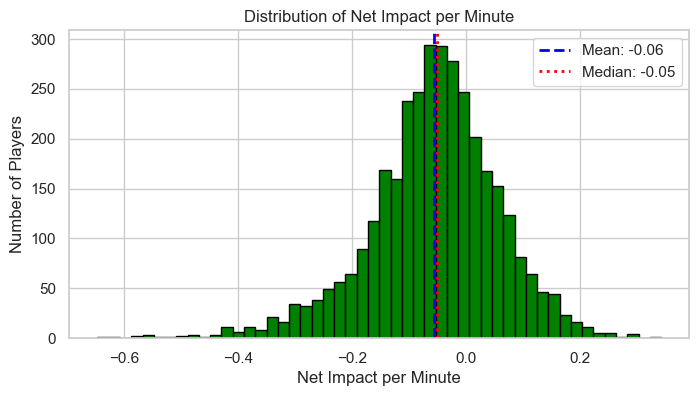

In [255]:
# Avoid division by zero for minutes
player_statistics['numMinutes_clean'] = player_statistics['numMinutes'].replace(0, np.nan)

# Compute raw Net Impact score per row (custom metric)
player_statistics['net_impact'] = (
    player_statistics['plusMinusPoints']
    + player_statistics['assists']
    + player_statistics['steals']
    + player_statistics['blocks']
    - player_statistics['turnovers']
    - player_statistics['foulsPersonal']
)

# Normalize Net Impact by minutes
player_statistics['net_impact_per_minute'] = (
    player_statistics['net_impact'] / player_statistics['numMinutes_clean']
)
# Group by player and aggregate totals
impact_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'net_impact': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Calculate Net Impact per Minute after aggregation
impact_summary['net_impact_per_minute'] = (
    impact_summary['net_impact'] / impact_summary['numMinutes']
)

# Filter: Keep only players with meaningful data
filtered_impact = impact_summary[
    (impact_summary['numGames'] >= 20) & 
    (impact_summary['numMinutes'] >= 200)
]

# Compute mean and median
impact_mean = filtered_impact['net_impact_per_minute'].mean()
impact_median = filtered_impact['net_impact_per_minute'].median()

# Plot histogram for Net Impact per Minute
plt.figure(figsize=(8, 4))
plt.hist(filtered_impact['net_impact_per_minute'].dropna(), bins=50, edgecolor='black', color='green')
plt.axvline(impact_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {impact_mean:.2f}')
plt.axvline(impact_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {impact_median:.2f}')
plt.title('Distribution of Net Impact per Minute')
plt.xlabel('Net Impact per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

In [256]:
# Sort by net impact per minute (descending) and select top 10
top10_net_impact = (
    filtered_impact
    .sort_values(by='net_impact_per_minute', ascending=False)
    .head(10)
)

# Display key info
print("Top 10 Players by Net Impact per Minute:")
display(top10_net_impact[[
    'firstName', 'lastName', 'numGames', 'numMinutes', 'net_impact_per_minute'
]])

Top 10 Players by Net Impact per Minute:


,firstName,lastName,numGames,numMinutes,net_impact_per_minute
2863,Chris,Paul,1342,44637.98,0.342354
181,John,Stockton,1504,47501.00,0.297804
427,Steve,Nash,1209,37490.00,0.291331
3597,Nikola,Jokic,737,23030.02,0.287625
3399,Draymond,Green,869,24580.13,0.283929
4358,Chet,Holmgren,107,3054.46,0.263549
3309,Kawhi,Leonard,724,22626.32,0.261907
770,Manu,Ginobili,1056,26330.00,0.260539
3164,Stephen,Curry,1015,34177.89,0.260519
266,Jason,Kidd,1391,49543.00,0.252851


### Note on Weighting in Net Impact Calculation

In the current version of the Net Impact Score, all included performance indicators are treated equally — each action (assist, steal, block, turnover, etc.) is assigned the same weight of 1.

While this approach provides a simple and interpretable composite score, it does not reflect the actual game impact of different actions. For example, a steal may be more valuable than a personal foul, and turnovers might carry a greater negative weight than missed field goals.

As a result, the current Net Impact per Minute metric should be seen as a baseline indicator, and future versions could apply data-driven or expert-defined weights to better reflect real in-game value.

## True Shooting Proxy (TS%)

The True Shooting Percentage (TS%) is a widely used efficiency metric that adjusts a player's scoring by taking into account all types of shots: 2-point field goals, 3-pointers, and free throws.

It estimates how efficiently a player converts scoring opportunities into points.

**Formula (proxy version):** TS% ≈ points / [2 × (fieldGoalsAttempted + 0.44 × freeThrowsAttempted)]

The **0.44 multiplier** accounts for the fact that free throw attempts do not always represent full possessions. In reality, a single free throw can occur after a made basket (e.g., an And-One), or as part of a multi-shot foul situation (two or three shots). Not every free throw results from a shooting foul, and not every trip to the line consumes the same amount of offensive opportunity. 

Based on long-term league data, it has been observed that, on average, one free throw attempt is roughly equivalent to **0.44 field goal attempts** in terms of possession usage. This adjustment ensures that True Shooting Percentage more accurately reflects a player’s scoring efficiency across all types of shots.

Typical TS% values:
- **~0.55** = average
- **> 0.60** = very efficient
- **< 0.50** = inefficient

This metric helps to highlight players who score effectively, not just frequently.

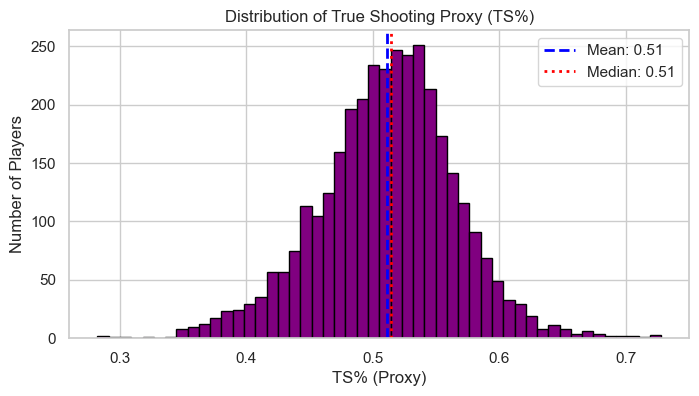

In [257]:
# Avoid division by zero
player_statistics['numMinutes_clean'] = player_statistics['numMinutes'].replace(0, np.nan)

# Calculate True Shooting Proxy
player_statistics['ts_proxy'] = player_statistics['points'] / (
    2 * (player_statistics['fieldGoalsAttempted'] + 0.44 * player_statistics['freeThrowsAttempted'])
)

# Group by player ID
ts_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'points': 'sum',
        'fieldGoalsAttempted': 'sum',
        'freeThrowsAttempted': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Calculate TS Proxy per player (aggregated version)
ts_summary['ts_proxy'] = ts_summary['points'] / (
    2 * (ts_summary['fieldGoalsAttempted'] + 0.44 * ts_summary['freeThrowsAttempted'])
)

# Filter: Only players with meaningful data
filtered_ts = ts_summary[
    (ts_summary['numGames'] >= 20) &
    (ts_summary['numMinutes'] >= 200)
]
# Calculate stats
ts_mean = filtered_ts['ts_proxy'].mean()
ts_median = filtered_ts['ts_proxy'].median()

# Plot
plt.figure(figsize=(8, 4))
plt.hist(filtered_ts['ts_proxy'].dropna(), bins=50, edgecolor='black', color='purple')
plt.axvline(ts_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {ts_mean:.2f}')
plt.axvline(ts_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {ts_median:.2f}')
plt.title('Distribution of True Shooting Proxy (TS%)')
plt.xlabel('TS% (Proxy)')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

In [258]:
# Sort by TS% descending and get top 10
top10_ts = (
    filtered_ts
    .sort_values(by='ts_proxy', ascending=False)
    .head(10)
)

# Display selected columns
print("Top 10 Players by True Shooting Proxy (TS%):")
display(top10_ts[['firstName', 'lastName', 'numGames', 'numMinutes', 'ts_proxy']])

Top 10 Players by True Shooting Proxy (TS%):


,firstName,lastName,numGames,numMinutes,ts_proxy
3978,Robert,Williams III,229,4646.60,0.727775
3910,Udoka,Azubuike,81,681.00,0.720989
4469,Dereck,Lively II,87,2032.63,0.718924
4077,Daniel,Gafford,372,7205.49,0.718019
4291,Jericho,Sims,187,2503.55,0.708803
4128,Donta,Hall,22,301.00,0.701052
4479,Adem,Bona,49,617.42,0.695610
3718,Damian,Jones,275,3651.00,0.695519
4585,Isaac,Jones,33,254.36,0.684223
4060,Jaxson,Hayes,354,5642.71,0.683327


## Turnover Rate per Minute

Turnovers represent lost scoring opportunities and are one of the most critical negative contributions a player can make. A high turnover rate often signals poor decision-making, lack of control, or risky play.

To make this metric fair across different playing times, we normalize turnovers by the number of minutes played:

Turnover Rate per Minute = turnovers / numMinutes

This metric helps identify players who are efficient ball handlers versus those who frequently give up possessions. While some turnovers are expected from high-usage playmakers, consistently high turnover rates can undermine a player’s overall value.

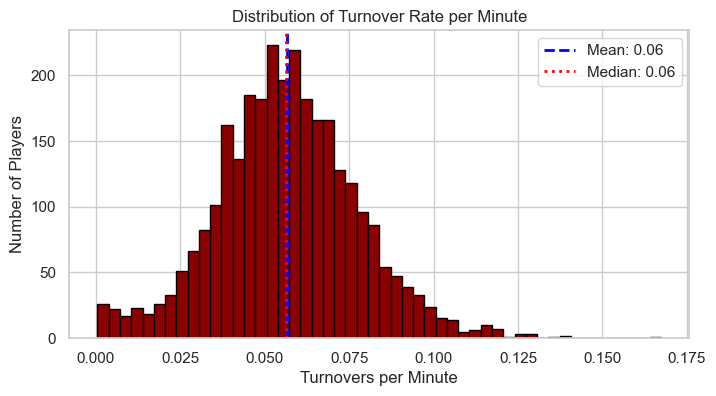

In [259]:
# Replace 0 minutes with NaN to avoid division by zero
player_statistics['numMinutes_clean'] = player_statistics['numMinutes'].replace(0, np.nan)

# Calculate Turnover Rate per Minute
player_statistics['turnover_per_minute'] = player_statistics['turnovers'] / player_statistics['numMinutes_clean']

# Group by player with full name
turnover_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'turnovers': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate turnover rate per minute after aggregation
turnover_summary['turnover_per_minute'] = turnover_summary['turnovers'] / turnover_summary['numMinutes']

# Filter: meaningful player samples
filtered_turnover = turnover_summary[
    (turnover_summary['numGames'] >= 20) &
    (turnover_summary['numMinutes'] >= 200) &
    (turnover_summary['turnovers'] > 0)
]

# Compute mean and median
turnover_mean = filtered_turnover['turnover_per_minute'].mean()
turnover_median = filtered_turnover['turnover_per_minute'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_turnover['turnover_per_minute'].dropna(), bins=50, edgecolor='black', color='darkred')
plt.axvline(turnover_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {turnover_mean:.2f}')
plt.axvline(turnover_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {turnover_median:.2f}')
plt.title('Distribution of Turnover Rate per Minute')
plt.xlabel('Turnovers per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

In [260]:
# Sort ascending: lowest turnover rates first
top10_lowest_turnover = (
    filtered_turnover
    .sort_values(by='turnover_per_minute', ascending=True)
    .head(10)
)

# Display key columns
print("Top 10 Players with Lowest Turnover Rate per Minute:")
display(top10_lowest_turnover[[
    'firstName', 'lastName', 'numGames', 'numMinutes', 'turnover_per_minute'
]])

Top 10 Players with Lowest Turnover Rate per Minute:


,firstName,lastName,numGames,numMinutes,turnover_per_minute
1116,Zaid,Abdul-Aziz,395,8578.0,0.000466
1247,Tom,Boerwinkle,525,11678.0,0.000599
2443,Cazzie,Russell,736,20296.0,0.000641
2824,Dave,Wohl,315,6162.0,0.000649
1727,Glenn,Hansen,109,1425.0,0.000702
1263,Fred,Boyd,293,6890.0,0.000871
1914,Robin,Jones,75,1134.0,0.000882
1753,Robert,Hawkins,101,1980.0,0.001010
1295,Gary,Brokaw,236,4635.0,0.001079
1154,Jim,Ard,217,2656.0,0.001130


## Rebounds per Minute

Rebounds are a key factor in controlling possession and momentum in a game. They are often overlooked in scoring-based evaluations, but highly valuable for both offense and defense.

To ensure fair comparisons between players with different playing times, we normalize total rebounds by the number of minutes played:

Rebounds per Minute = reboundsTotal / numMinutes


Optionally, we can separate offensive and defensive rebounds to highlight a player's role more clearly:

- **Offensive Rebounds per Minute**: Indicates second-chance creation
- **Defensive Rebounds per Minute**: Reflects possession recovery

This metric is especially useful for evaluating big men, but can also uncover hustle players at other positions.

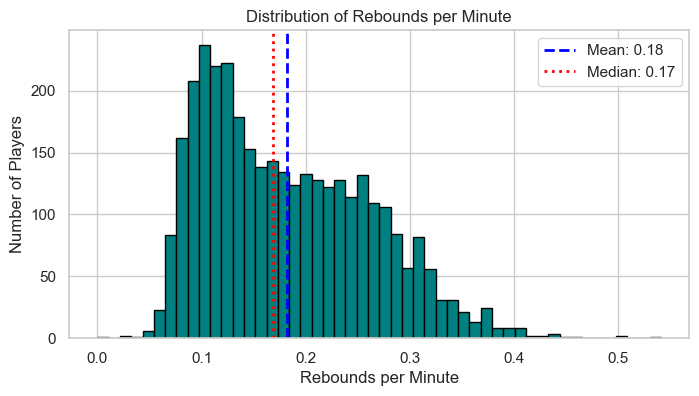

In [261]:
# Calculate rebounds per minute
player_statistics['rebounds_per_minute'] = (
    player_statistics['reboundsTotal'] / player_statistics['numMinutes_clean']
)

# Aggregate per player
rebound_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsTotal': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate after aggregation
rebound_summary['rebounds_per_minute'] = rebound_summary['reboundsTotal'] / rebound_summary['numMinutes']

# Filter meaningful samples
filtered_rebound = rebound_summary[
    (rebound_summary['numGames'] >= 20) &
    (rebound_summary['numMinutes'] >= 200)
]

# Plot distribution
rebound_mean = filtered_rebound['rebounds_per_minute'].mean()
rebound_median = filtered_rebound['rebounds_per_minute'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_rebound['rebounds_per_minute'].dropna(), bins=50, edgecolor='black', color='teal')
plt.axvline(rebound_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {rebound_mean:.2f}')
plt.axvline(rebound_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {rebound_median:.2f}')
plt.title('Distribution of Rebounds per Minute')
plt.xlabel('Rebounds per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

In [262]:
# Sort descending to get top rebounders per minute
top10_rebounders = (
    filtered_rebound
    .sort_values(by='rebounds_per_minute', ascending=False)
    .head(10)
)

# Display relevant columns
print("Top 10 Players by Rebounds per Minute:")
display(top10_rebounders[[
    'firstName', 'lastName', 'numGames', 'numMinutes', 'rebounds_per_minute'
]])

Top 10 Players by Rebounds per Minute:


,firstName,lastName,numGames,numMinutes,rebounds_per_minute
2447,Bill,Russell,620,25937.00,0.541273
1371,Wilt,Chamberlain,1000,45802.00,0.499804
3630,Maurice,Stokes,31,1140.00,0.498246
3372,Andre,Drummond,904,23803.20,0.461325
3256,Hassan,Whiteside,511,12389.00,0.445799
3682,Alan,Williams,65,840.00,0.441667
4073,Moses,Brown,156,1832.94,0.436457
3688,Boban,Marjanovic,317,2736.00,0.434211
2780,Earl,Williams,145,1841.00,0.432917
3936,Alize,Johnson,73,532.00,0.428571


### Offensive vs Defensive (distributions)

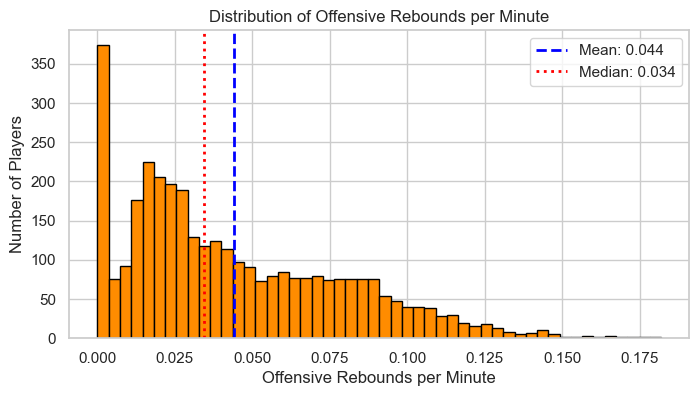

In [263]:
# Calculate offensive rebounds per minute
player_statistics['off_reb_per_minute'] = (
    player_statistics['reboundsOffensive'] / player_statistics['numMinutes_clean']
)

# Aggregate per player
off_reb_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsOffensive': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Calculate per-minute value
off_reb_summary['off_reb_per_minute'] = (
    off_reb_summary['reboundsOffensive'] / off_reb_summary['numMinutes']
)

# Filter relevant players
filtered_off_reb = off_reb_summary[
    (off_reb_summary['numGames'] >= 20) &
    (off_reb_summary['numMinutes'] >= 200)
]

# Plot
off_reb_mean = filtered_off_reb['off_reb_per_minute'].mean()
off_reb_median = filtered_off_reb['off_reb_per_minute'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_off_reb['off_reb_per_minute'].dropna(), bins=50, edgecolor='black', color='darkorange')
plt.axvline(off_reb_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {off_reb_mean:.3f}')
plt.axvline(off_reb_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {off_reb_median:.3f}')
plt.title('Distribution of Offensive Rebounds per Minute')
plt.xlabel('Offensive Rebounds per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

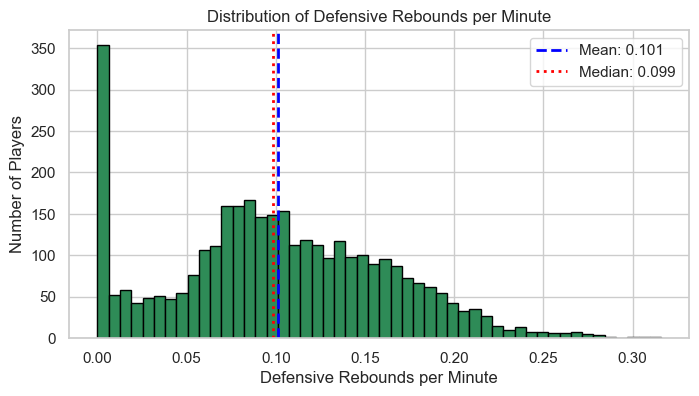

In [264]:
# Calculate defensive rebounds per minute
player_statistics['def_reb_per_minute'] = (
    player_statistics['reboundsDefensive'] / player_statistics['numMinutes_clean']
)

# Aggregate per player
def_reb_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsDefensive': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Calculate per-minute value
def_reb_summary['def_reb_per_minute'] = (
    def_reb_summary['reboundsDefensive'] / def_reb_summary['numMinutes']
)

# Filter relevant players
filtered_def_reb = def_reb_summary[
    (def_reb_summary['numGames'] >= 20) &
    (def_reb_summary['numMinutes'] >= 200)
]

# Plot
def_reb_mean = filtered_def_reb['def_reb_per_minute'].mean()
def_reb_median = filtered_def_reb['def_reb_per_minute'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_def_reb['def_reb_per_minute'].dropna(), bins=50, edgecolor='black', color='seagreen')
plt.axvline(def_reb_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {def_reb_mean:.3f}')
plt.axvline(def_reb_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {def_reb_median:.3f}')
plt.title('Distribution of Defensive Rebounds per Minute')
plt.xlabel('Defensive Rebounds per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

## Plus/Minus per Minute

The Plus/Minus statistic indicates how the score changes while a player is on the court — it measures whether the team outscores or is outscored by the opponent during that time.

To make it comparable across players with different playing times, we normalize it:

Plus/Minus per Minute = plusMinusPoints / numMinutes


- A **positive value** means the team scored more than the opponent while the player was on the court.
- A **negative value** indicates the opposite.

This metric reflects overall game influence, including off-ball impact, defense, spacing, and intangibles. While it can be affected by team quality and rotations, it provides a useful signal for on-court effectiveness —> especially over large samples.




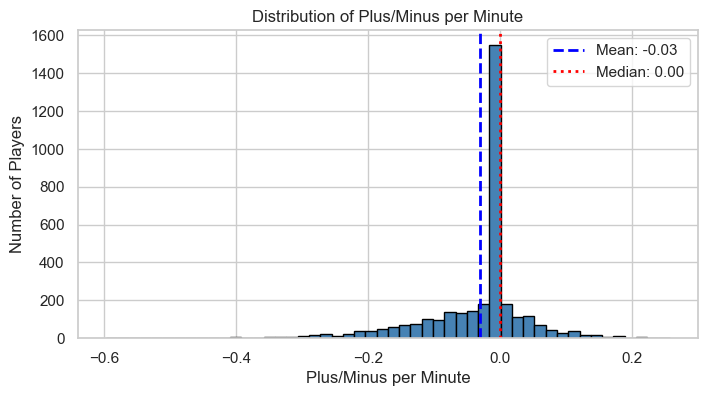

In [265]:
# Avoid division by zero
player_statistics['numMinutes_clean'] = player_statistics['numMinutes'].replace(0, np.nan)

# Calculate Plus/Minus per Minute
player_statistics['plus_minus_per_minute'] = player_statistics['plusMinusPoints'] / player_statistics['numMinutes_clean']

# Group by player
pm_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'plusMinusPoints': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate per-minute metric
pm_summary['plus_minus_per_minute'] = pm_summary['plusMinusPoints'] / pm_summary['numMinutes']

# Filter meaningful samples
filtered_pm = pm_summary[
    (pm_summary['numGames'] >= 20) &
    (pm_summary['numMinutes'] >= 200)
]

# Stats
pm_mean = filtered_pm['plus_minus_per_minute'].mean()
pm_median = filtered_pm['plus_minus_per_minute'].median()

# Plot
plt.figure(figsize=(8, 4))
plt.hist(filtered_pm['plus_minus_per_minute'].dropna(), bins=50, edgecolor='black', color='steelblue')
plt.axvline(pm_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {pm_mean:.2f}')
plt.axvline(pm_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {pm_median:.2f}')
plt.title('Distribution of Plus/Minus per Minute')
plt.xlabel('Plus/Minus per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

The distribution reveals that most players have a neutral impact on the score while on the court, with values clustering around zero. Only a few players show a consistently strong positive or negative influence per minute, as seen in the distribution's tails.

In [266]:
# Sort descending to get highest plus-minus per minute players
top10_plus_minus = (
    filtered_pm
    .sort_values(by='plus_minus_per_minute', ascending=False)
    .head(10)
)

# Display relevant columns
print("Top 10 Players by Plus/Minus per Minute:")
display(top10_plus_minus[[
    'firstName', 'lastName', 'numGames', 'numMinutes', 'plus_minus_per_minute'
]])


Top 10 Players by Plus/Minus per Minute:


,firstName,lastName,numGames,numMinutes,plus_minus_per_minute
833,Igor,Rakocevic,31,222.00,0.256757
3509,Gigi,Datome,52,424.00,0.240566
4286,Sam,Hauser,246,4404.44,0.230903
4113,Devontae,Cacok,36,209.00,0.220096
4501,Jordan,Walsh,55,428.81,0.216879
4358,Chet,Holmgren,107,3054.46,0.215423
4094,Neemias,Queta,100,1219.83,0.211505
4178,Isaiah,Joe,306,5077.36,0.209755
770,Manu,Ginobili,1056,26330.00,0.207976
4568,Ajay,Mitchell,34,553.53,0.205951


### Defensive Activity: Blocks and Steals per Minute

Blocks and steals are key indicators of defensive presence and activity. While they don't capture every defensive action (like positioning or help defense), they highlight players who disrupt the opponent's offense through shot denial or ball pressure.

To adjust for varying playing time, both metrics are normalized per minute:

Blocks per Minute = blocks / numMinutes
Steals per Minute = steals / numMinutes

Players with high values tend to be rim protectors, aggressive defenders, or opportunistic playmakers. These stats help reveal defensive specialists who might not show up in scoring metrics.

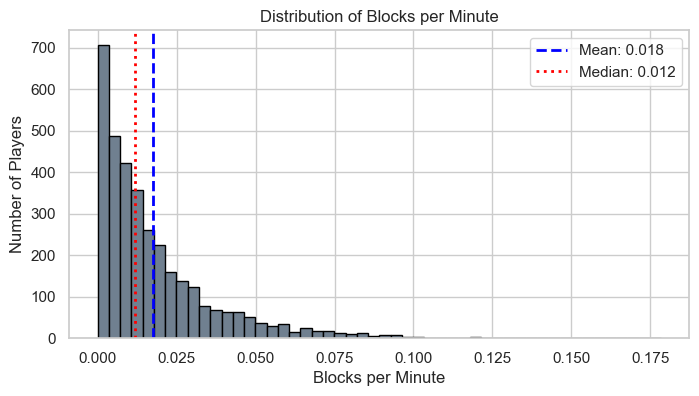

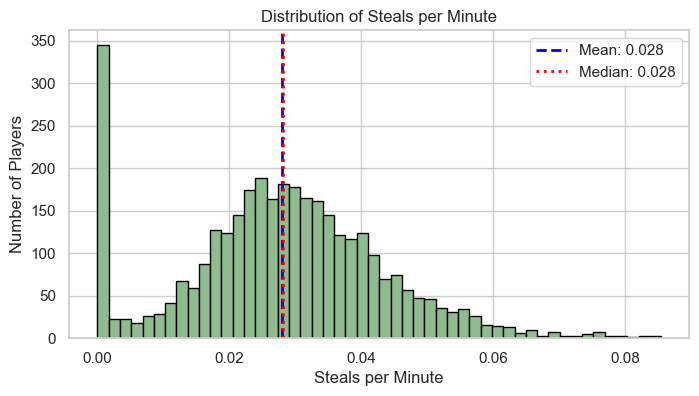

In [267]:
# Defensive metrics per minute
player_statistics['blocks_per_minute'] = player_statistics['blocks'] / player_statistics['numMinutes_clean']
player_statistics['steals_per_minute'] = player_statistics['steals'] / player_statistics['numMinutes_clean']

# Aggregation
defense_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'blocks': 'sum',
        'steals': 'sum',
        'numMinutes': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Per-minute calculations
defense_summary['blocks_per_minute'] = defense_summary['blocks'] / defense_summary['numMinutes']
defense_summary['steals_per_minute'] = defense_summary['steals'] / defense_summary['numMinutes']

# Filter meaningful samples
filtered_defense = defense_summary[
    (defense_summary['numGames'] >= 20) & (defense_summary['numMinutes'] >= 200)
]

# Histogram – Blocks
blocks_mean = filtered_defense['blocks_per_minute'].mean()
blocks_median = filtered_defense['blocks_per_minute'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_defense['blocks_per_minute'].dropna(), bins=50, edgecolor='black', color='slategray')
plt.axvline(blocks_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {blocks_mean:.3f}')
plt.axvline(blocks_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {blocks_median:.3f}')
plt.title('Distribution of Blocks per Minute')
plt.xlabel('Blocks per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

# Histogram – Steals
steals_mean = filtered_defense['steals_per_minute'].mean()
steals_median = filtered_defense['steals_per_minute'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_defense['steals_per_minute'].dropna(), bins=50, edgecolor='black', color='darkseagreen')
plt.axvline(steals_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {steals_mean:.3f}')
plt.axvline(steals_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {steals_median:.3f}')
plt.title('Distribution of Steals per Minute')
plt.xlabel('Steals per Minute')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### Note on Distribution Peaks at 0.0 (Blocks & Steals per Minute)

The strong peak at 0.0 in both the blocks and steals distributions is not a data error -> it reflects real player roles and play styles.

Many players, especially guards in the case of blocks or big men in the case of steals, may contribute little or nothing to these specific defensive actions. Others may have low playing time or play passively on defense.

These players naturally cluster near zero in per-minute metrics. Depending on the analysis goal, it may be useful to either keep them as part of the overall distribution or filter them out to focus on defensively active players.


# Normalizing by Possessions: A More Context-Aware Approach

While per-minute statistics are useful for quick comparisons, they can overlook the varying pace and playing styles between teams. Not all minutes are created equal —> a player on a fast-paced team will experience more offensive and defensive actions per minute than one on a slower-paced team. 

Normalizing by possessions offers a more accurate measure of a player's impact, as it reflects how often they are involved in meaningful game situations. It accounts for tempo, system differences, and provides a fairer basis for comparing players across roles and teams. In the following section, we explore how to derive possession-based performance metrics using team-level data.


The number of possessions is estimated as $\text{Possessions} \approx \text{FGA} + 0.44 \times \text{FTA} - \text{ORB} + \text{TO}$.


This approximation accounts for field goal attempts (FGA), free throw attempts (FTA), offensive rebounds (ORB), and turnovers (TO). It does not require opponent rebounding data, making it suitable for our available dataset.
To estimate the number of possessions a player was involved in, we assume that team possessions are evenly distributed across the 240 available player-minutes (48 minutes × 5 players). A player's share of possessions is then proportional to their minutes played:

$$
\text{Player Possessions} = \text{Team Possessions} \times \frac{\text{Player Minutes}}{240}
$$


In [268]:
team_statistics = pd.read_csv(os.path.join(DATA_PATH, "team_statistics_v2.csv"))

In [269]:
player_statistics = pd.read_csv(os.path.join(DATA_PATH, "player_statistics_v2.csv"), low_memory=False)

# Convert 'gameDate' from string to datetime format
player_statistics['gameDate'] = pd.to_datetime(player_statistics['gameDate'], errors='coerce')

# Step 1+2: Convert 'numMinutes' in 'MM:SS' format directly to float minutes
def parse_minutes(min_str):
    if isinstance(min_str, str) and ':' in min_str:
        minutes, seconds = map(int, min_str.split(":"))
        return minutes + seconds / 60
    return np.nan

player_statistics['numMinutes'] = player_statistics['numMinutes'].apply(parse_minutes)

# Step 3: Filter rows where numMinutes > 0
player_statistics = player_statistics[player_statistics['numMinutes'] > 0].copy()

# Check data types and missing values
print(player_statistics['gameDate'].dtype)              # should be datetime64[ns]
print(player_statistics['numMinutes'].dtype)            # should be float64
print(player_statistics['numMinutes'].isna().sum())     # count missing values after conversion

# Drop irrelevant columns that are not really useful for analysis
# 'jerseyNum': mostly missing and not analytically relevant
# 'gameLabel' and 'gameSubLabel': contain only NaN values
player_statistics.drop(columns=['jerseyNum', 'gameLabel', 'gameSubLabel'], inplace=True)

datetime64[ns]
float64
0


In [270]:
team_statistics["possessions"] = (
    team_statistics["fieldGoalsAttempted"]
    + 0.44 * team_statistics["freeThrowsAttempted"]
    - team_statistics["reboundsOffensive"]
    + team_statistics["turnovers"]
)

# Merge team possessions into player statistics based on gameId and teamId
player_statistics = player_statistics.merge(
    team_statistics[["gameId", "teamId", "possessions"]],
    on=["gameId", "teamId"],
    how="left"
)

# Estimate player possessions based on minutes played
player_statistics["player_possessions"] = (
    player_statistics["numMinutes"] / 240
) * player_statistics["possessions"]


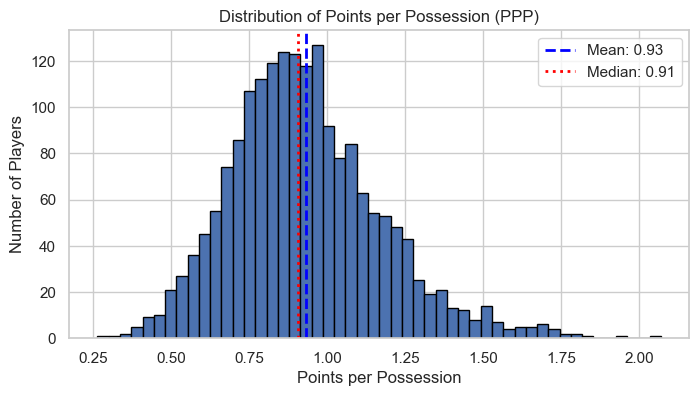

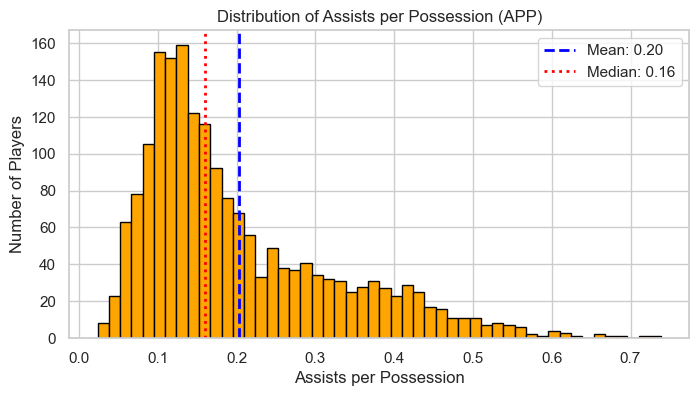

In [271]:
# Group by player and aggregate total stats and possessions
player_summary_poss = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'points': 'sum',
        'assists': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Avoid division by zero: replace 0 possessions with NaN
player_summary_poss['player_possessions'] = player_summary_poss['player_possessions'].replace(0, np.nan)

# Calculate Points per Possession (PPP) and Assists per Possession (APP)
player_summary_poss['points_per_possession'] = player_summary_poss['points'] / player_summary_poss['player_possessions']
player_summary_poss['assists_per_possession'] = player_summary_poss['assists'] / player_summary_poss['player_possessions']

# Filter: Keep only players with at least 20 games and 200 possessions
filtered_poss_players = player_summary_poss[
    (player_summary_poss['numGames'] >= 20) &
    (player_summary_poss['player_possessions'] >= 200)
]

# Compute stats
ppp_mean = filtered_poss_players['points_per_possession'].mean()
ppp_median = filtered_poss_players['points_per_possession'].median()

# Plot histogram: Points per Possession
plt.figure(figsize=(8, 4))
plt.hist(filtered_poss_players['points_per_possession'].dropna(), bins=50, edgecolor='black')
plt.axvline(ppp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {ppp_mean:.2f}')
plt.axvline(ppp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {ppp_median:.2f}')
plt.title('Distribution of Points per Possession (PPP)')
plt.xlabel('Points per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

# Compute stats
app_mean = filtered_poss_players['assists_per_possession'].mean()
app_median = filtered_poss_players['assists_per_possession'].median()

# Plot histogram: Assists per Possession
plt.figure(figsize=(8, 4))
plt.hist(filtered_poss_players['assists_per_possession'].dropna(), bins=50, edgecolor='black', color='orange')
plt.axvline(app_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {app_mean:.2f}')
plt.axvline(app_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {app_median:.2f}')
plt.title('Distribution of Assists per Possession (APP)')
plt.xlabel('Assists per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### Points per Possession (PPP)

The `points_per_possession` metric captures a player's overall scoring efficiency by dividing their total points by their estimated number of offensive possessions played. It provides a pace-independent measure, making comparisons between players with different playing times more meaningful. The distribution of PPP among players is approximately symmetric, with a mean around 0.93 and a median near 0.91, indicating that most players score close to one point per possession. This metric is fundamental for assessing individual offensive impact and is robust enough for inclusion in further analysis and modeling.

---

### Assists per Possession (APP)

The `assists_per_possession` metric reflects a player's playmaking contribution, defined as the total number of assists divided by estimated possessions played. Its distribution is strongly right-skewed, which is expected, as assists are typically concentrated among primary ball handlers. The mean is approximately 0.20 and the median around 0.16, suggesting that most players assist on roughly 1 out of every 5–6 possessions. This metric is particularly useful to identify players with high facilitation value and complements scoring-based efficiency metrics in player evaluation.


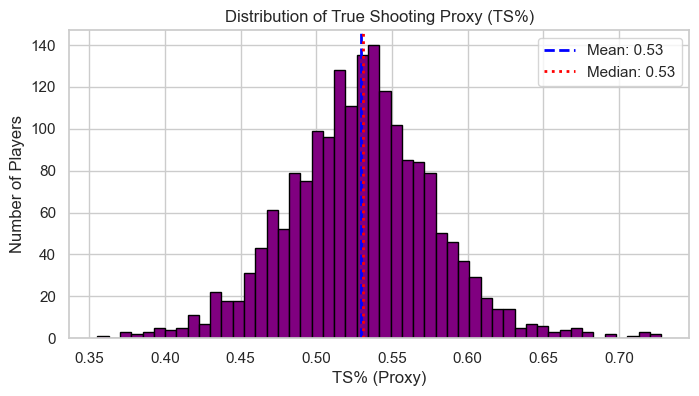

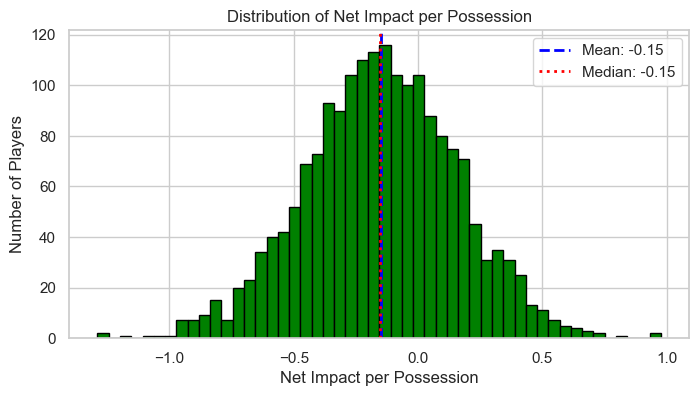

In [272]:
# Avoid division by zero by replacing 0 possessions with NaN
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate True Shooting Proxy per possession (per row)
player_statistics['ts_proxy_possession'] = player_statistics['points'] / (
    2 * (player_statistics['fieldGoalsAttempted'] + 0.44 * player_statistics['freeThrowsAttempted'])
)

# Compute raw Net Impact score per row (custom metric)
player_statistics['net_impact'] = (
    player_statistics['plusMinusPoints']
    + player_statistics['assists']
    + player_statistics['steals']
    + player_statistics['blocks']
    - player_statistics['turnovers']
    - player_statistics['foulsPersonal']
)

# Normalize Net Impact by possessions
player_statistics['net_impact_per_possession'] = (
    player_statistics['net_impact'] / player_statistics['player_possessions']
)
# Group stats by player and aggregate relevant totals
impact_ts_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'points': 'sum',
        'fieldGoalsAttempted': 'sum',
        'freeThrowsAttempted': 'sum',
        'net_impact': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Calculate True Shooting Proxy from aggregated values
impact_ts_summary['ts_proxy'] = impact_ts_summary['points'] / (
    2 * (impact_ts_summary['fieldGoalsAttempted'] + 0.44 * impact_ts_summary['freeThrowsAttempted'])
)

# Calculate Net Impact per Possession from aggregated values
impact_ts_summary['net_impact_per_possession'] = (
    impact_ts_summary['net_impact'] / impact_ts_summary['player_possessions']
)

# Filter: Keep only players with meaningful sample size
filtered_ts_impact = impact_ts_summary[
    (impact_ts_summary['numGames'] >= 20) &
    (impact_ts_summary['player_possessions'] >= 200)
]

# Compute mean and median
ts_mean = filtered_ts_impact['ts_proxy'].mean()
ts_median = filtered_ts_impact['ts_proxy'].median()

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(filtered_ts_impact['ts_proxy'].dropna(), bins=50, edgecolor='black', color='purple')
plt.axvline(ts_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {ts_mean:.2f}')
plt.axvline(ts_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {ts_median:.2f}')
plt.title('Distribution of True Shooting Proxy (TS%)')
plt.xlabel('TS% (Proxy)')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

# Compute mean and median
nip_mean = filtered_ts_impact['net_impact_per_possession'].mean()
nip_median = filtered_ts_impact['net_impact_per_possession'].median()

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(filtered_ts_impact['net_impact_per_possession'].dropna(), bins=50, edgecolor='black', color='green')
plt.axvline(nip_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {nip_mean:.2f}')
plt.axvline(nip_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {nip_median:.2f}')
plt.title('Distribution of Net Impact per Possession')
plt.xlabel('Net Impact per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### True Shooting Proxy (TS%)

The `ts_proxy` approximates a player's true shooting percentage by relating total points scored to the combined total of field goal and free throw attempts. It is calculated as:

$$
TS\% \approx \frac{\text{Points}}{2 \times (\text{FGA} + 0.44 \times \text{FTA})}
$$

This proxy metric balances scoring efficiency with the ability to draw fouls and is used as a pace- and volume-independent shooting efficiency indicator. The observed distribution centers around 0.53. This makes it a valuable tool for comparing players’ scoring quality independent of usage volume.

---

### Net Impact per Possession

The `net_impact_per_possession` metric is a custom-designed score that estimates a player's holistic contribution per possession. It aggregates positive events (plus-minus points, assists, steals, blocks) and subtracts negative ones (turnovers, personal fouls), normalized by the number of possessions played:

$$
\text{Net Impact per Possession} = \frac{\text{+/-} + \text{AST} + \text{STL} + \text{BLK} - \text{TO} - \text{FOULS}}{\text{Player Possessions}}
$$

While the weights are not statistically optimized, this metric offers an exploratory perspective on all-around player performance beyond just scoring. The average value is slightly negative (≈ –0.15), which is expected given role distributions across teams. It is best interpreted as a heuristic and should be refined or validated before use in predictive modeling.


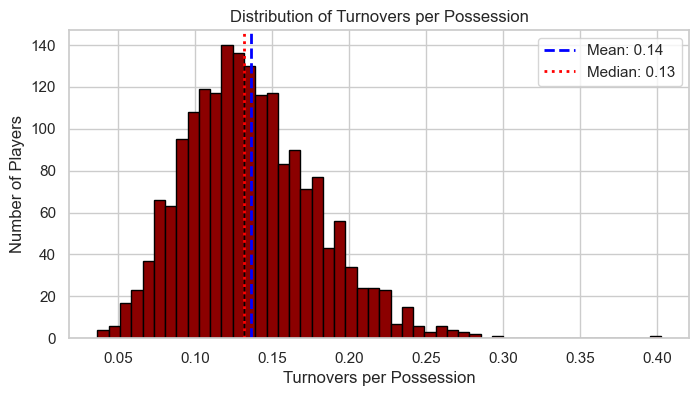

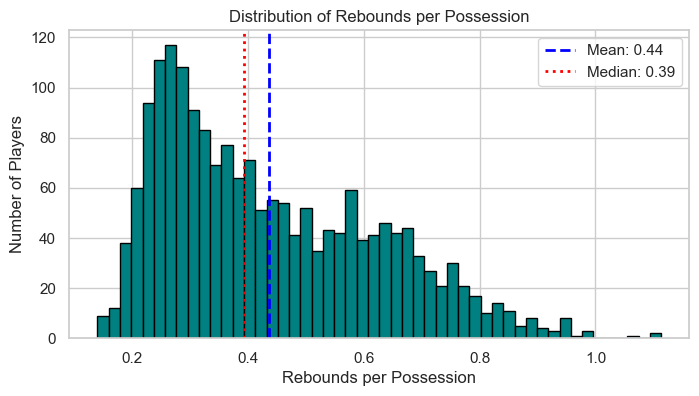

In [273]:
# Avoid division by zero
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate turnover rate per possession
player_statistics['turnovers_per_possession'] = (
    player_statistics['turnovers'] / player_statistics['player_possessions']
)

# Group by player and aggregate totals
turnover_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'turnovers': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate turnover rate after aggregation
turnover_poss_summary['turnovers_per_possession'] = (
    turnover_poss_summary['turnovers'] / turnover_poss_summary['player_possessions']
)

# Filter meaningful samples
filtered_turnover_poss = turnover_poss_summary[
    (turnover_poss_summary['numGames'] >= 20) &
    (turnover_poss_summary['player_possessions'] >= 200) &
    (turnover_poss_summary['turnovers'] > 0)
]

# Compute mean and median
topp_mean = filtered_turnover_poss['turnovers_per_possession'].mean()
topp_median = filtered_turnover_poss['turnovers_per_possession'].median()

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(filtered_turnover_poss['turnovers_per_possession'].dropna(), bins=50, edgecolor='black', color='darkred')
plt.axvline(topp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {topp_mean:.2f}')
plt.axvline(topp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {topp_median:.2f}')
plt.title('Distribution of Turnovers per Possession')
plt.xlabel('Turnovers per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

# Calculate rebounds per possession
player_statistics['rebounds_per_possession'] = (
    player_statistics['reboundsTotal'] / player_statistics['player_possessions']
)

# Aggregate totals per player
rebound_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsTotal': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate per possession metric
rebound_poss_summary['rebounds_per_possession'] = (
    rebound_poss_summary['reboundsTotal'] / rebound_poss_summary['player_possessions']
)

# Filter meaningful samples
filtered_rebound_poss = rebound_poss_summary[
    (rebound_poss_summary['numGames'] >= 20) &
    (rebound_poss_summary['player_possessions'] >= 200)
]

# Compute stats
rpp_mean = filtered_rebound_poss['rebounds_per_possession'].mean()
rpp_median = filtered_rebound_poss['rebounds_per_possession'].median()

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(filtered_rebound_poss['rebounds_per_possession'].dropna(), bins=50, edgecolor='black', color='teal')
plt.axvline(rpp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {rpp_mean:.2f}')
plt.axvline(rpp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {rpp_median:.2f}')
plt.title('Distribution of Rebounds per Possession')
plt.xlabel('Rebounds per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### Turnovers per Possession (TOPP)

The `turnovers_per_possession` metric captures the frequency of a player's ball losses relative to their estimated number of possessions. It is defined as:

$$
\text{Turnovers per Possession} = \frac{\text{Turnovers}}{\text{Player Possessions}}
$$

This metric is a key indicator of offensive risk and decision-making. A value of 0.14 (mean) suggests that players turn the ball over approximately once every 7 possessions. TOPP could be useful when combined with assists for assessing playmaking efficiency.

---

### Rebounds per Possession (RPP)

The `rebounds_per_possession` metric reflects a player's overall rebounding activity, normalized by their possessions played. It includes both offensive and defensive rebounds:

$$
\text{Rebounds per Possession} = \frac{\text{Total Rebounds}}{\text{Player Possessions}}
$$

With a mean of 0.44 and a median of 0.39, this metric shows considerable variation across positions. It is useful for evaluating a player's contribution to maintaining or regaining possession, particularly for big men or hustle players.


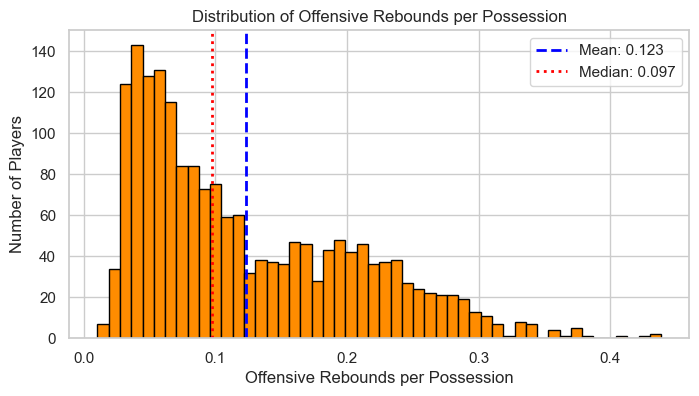

In [274]:
# Avoid division by zero
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate offensive rebounds per possession (per row)
player_statistics['off_reb_per_possession'] = (
    player_statistics['reboundsOffensive'] / player_statistics['player_possessions']
)

# Aggregate offensive rebounds and possessions per player
off_reb_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsOffensive': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate offensive rebounds per possession after aggregation
off_reb_poss_summary['off_reb_per_possession'] = (
    off_reb_poss_summary['reboundsOffensive'] / off_reb_poss_summary['player_possessions']
)

# Filter players with a meaningful sample size
filtered_off_reb_poss = off_reb_poss_summary[
    (off_reb_poss_summary['numGames'] >= 20) &
    (off_reb_poss_summary['player_possessions'] >= 200)
]

# Compute mean and median
orpp_mean = filtered_off_reb_poss['off_reb_per_possession'].mean()
orpp_median = filtered_off_reb_poss['off_reb_per_possession'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_off_reb_poss['off_reb_per_possession'].dropna(), bins=50, edgecolor='black', color='darkorange')
plt.axvline(orpp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {orpp_mean:.3f}')
plt.axvline(orpp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {orpp_median:.3f}')
plt.title('Distribution of Offensive Rebounds per Possession')
plt.xlabel('Offensive Rebounds per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

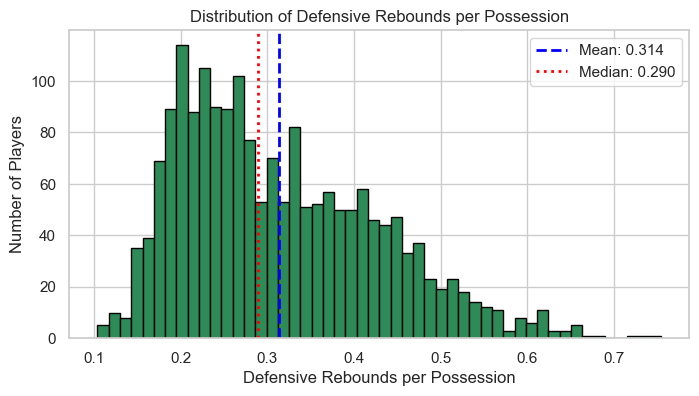

In [275]:
# Avoid division by zero
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate defensive rebounds per possession (per row)
player_statistics['def_reb_per_possession'] = (
    player_statistics['reboundsDefensive'] / player_statistics['player_possessions']
)

# Aggregate defensive rebounds and possessions per player
def_reb_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'reboundsDefensive': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate metric after aggregation
def_reb_poss_summary['def_reb_per_possession'] = (
    def_reb_poss_summary['reboundsDefensive'] / def_reb_poss_summary['player_possessions']
)

# Filter players with meaningful sample size
filtered_def_reb_poss = def_reb_poss_summary[
    (def_reb_poss_summary['numGames'] >= 20) &
    (def_reb_poss_summary['player_possessions'] >= 200)
]

# Compute mean and median
drpp_mean = filtered_def_reb_poss['def_reb_per_possession'].mean()
drpp_median = filtered_def_reb_poss['def_reb_per_possession'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_def_reb_poss['def_reb_per_possession'].dropna(), bins=50, edgecolor='black', color='seagreen')
plt.axvline(drpp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {drpp_mean:.3f}')
plt.axvline(drpp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {drpp_median:.3f}')
plt.title('Distribution of Defensive Rebounds per Possession')
plt.xlabel('Defensive Rebounds per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### Offensive Rebounds per Possession (ORPP)

The `off_reb_per_possession` metric quantifies how frequently a player recovers missed shots by their own team, thus extending possessions and creating second-chance opportunities. It is calculated as:

$$
\text{ORPP} = \frac{\text{Offensive Rebounds}}{\text{Player Possessions}}
$$

The distribution is highly right-skewed, with a mean of 0.123 and a median of 0.097. This reflects the fact that most players grab relatively few offensive boards, while a small group—typically frontcourt players—contribute significantly in this area. This metric is particularly helpful for identifying hustle players and rebound specialists on the offensive end.

---

### Defensive Rebounds per Possession (DRPP)

The `def_reb_per_possession` metric measures a player's ability to end the opponent’s possession by securing the defensive rebound. It is defined as:

$$
\text{DRPP} = \frac{\text{Defensive Rebounds}}{\text{Player Possessions}}
$$

The distribution is more balanced compared to ORPP, with a mean of 0.314 and a median of 0.290. This suggests that while certain players dominate defensive rebounding, the contribution is more evenly spread across player roles than on the offensive end. DRPP provides valuable insights into a player's defensive presence and rebounding positioning.

---

When using both `ORPP` and `DRPP`, be cautious not to introduce redundancy if `total_rebounds_per_possession` is also included in your model, as the three variables are linearly dependent.


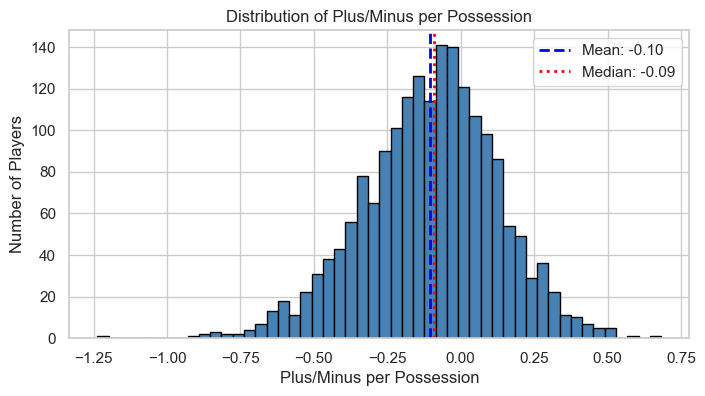

In [276]:
# Avoid division by zero for possessions
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate Plus/Minus per Possession (per row)
player_statistics['plus_minus_per_possession'] = (
    player_statistics['plusMinusPoints'] / player_statistics['player_possessions']
)

# Aggregate total Plus/Minus and possessions per player
pm_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'plusMinusPoints': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate Plus/Minus per Possession after aggregation
pm_poss_summary['plus_minus_per_possession'] = (
    pm_poss_summary['plusMinusPoints'] / pm_poss_summary['player_possessions']
)

# Filter: only players with meaningful possessions and game count
filtered_pm_poss = pm_poss_summary[
    (pm_poss_summary['numGames'] >= 20) &
    (pm_poss_summary['player_possessions'] >= 200)
]

# Compute mean and median
pmpp_mean = filtered_pm_poss['plus_minus_per_possession'].mean()
pmpp_median = filtered_pm_poss['plus_minus_per_possession'].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_pm_poss['plus_minus_per_possession'].dropna(), bins=50, edgecolor='black', color='steelblue')
plt.axvline(pmpp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {pmpp_mean:.2f}')
plt.axvline(pmpp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {pmpp_median:.2f}')
plt.title('Distribution of Plus/Minus per Possession')
plt.xlabel('Plus/Minus per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()


### Plus/Minus per Possession (PMPP)

The `plus_minus_per_possession` metric captures the net point differential of a player's team while they are on the court, normalized by estimated player possessions:

$$
\text{PMPP} = \frac{\text{Plus/Minus Points}}{\text{Player Possessions}}
$$

This metric is a direct impact indicator. It reflects how the team performs with the player on the floor compared to when they are off. A positive PMPP suggests that the team gains points per possession when the player is involved, while a negative value indicates a net loss.

The distribution is approximately normal with a mean of –0.10 and a median of –0.09. PMPP is particularly valuable as a signal for a player’s influence on team success, although it should be interpreted carefully in context with lineup effects and team strength.

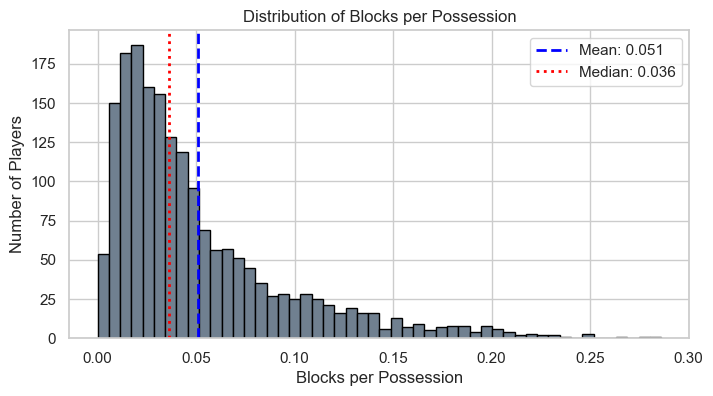

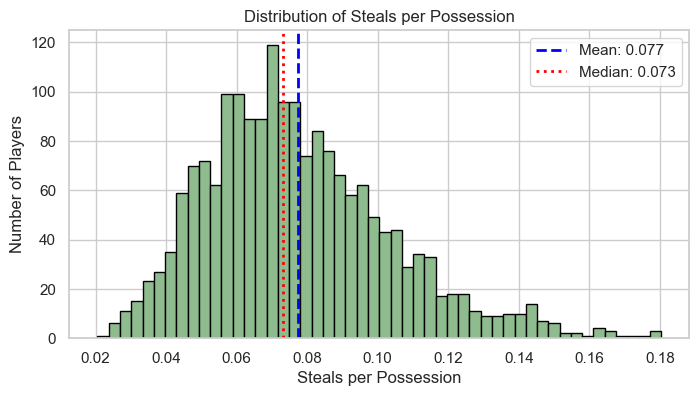

In [277]:
# Avoid division by zero
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Calculate defensive metrics per possession (row level)
player_statistics['blocks_per_possession'] = player_statistics['blocks'] / player_statistics['player_possessions']
player_statistics['steals_per_possession'] = player_statistics['steals'] / player_statistics['player_possessions']

# Aggregate total blocks, steals, and possessions per player
defense_poss_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'blocks': 'sum',
        'steals': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate per-possession values after aggregation
defense_poss_summary['blocks_per_possession'] = (
    defense_poss_summary['blocks'] / defense_poss_summary['player_possessions']
)
defense_poss_summary['steals_per_possession'] = (
    defense_poss_summary['steals'] / defense_poss_summary['player_possessions']
)

# Filter meaningful player samples
filtered_defense_poss = defense_poss_summary[
    (defense_poss_summary['numGames'] >= 20) &
    (defense_poss_summary['player_possessions'] >= 200)
]

blocks_mean = filtered_defense_poss['blocks_per_possession'].mean()
blocks_median = filtered_defense_poss['blocks_per_possession'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_defense_poss['blocks_per_possession'].dropna(), bins=50, edgecolor='black', color='slategray')
plt.axvline(blocks_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {blocks_mean:.3f}')
plt.axvline(blocks_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {blocks_median:.3f}')
plt.title('Distribution of Blocks per Possession')
plt.xlabel('Blocks per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

steals_mean = filtered_defense_poss['steals_per_possession'].mean()
steals_median = filtered_defense_poss['steals_per_possession'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_defense_poss['steals_per_possession'].dropna(), bins=50, edgecolor='black', color='darkseagreen')
plt.axvline(steals_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {steals_mean:.3f}')
plt.axvline(steals_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {steals_median:.3f}')
plt.title('Distribution of Steals per Possession')
plt.xlabel('Steals per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.show()

### Blocks per Possession (BPP)

The `blocks_per_possession` metric measures how frequently a player blocks opponent shots per estimated possession played:

$$
\text{BPP} = \frac{\text{Blocks}}{\text{Player Possessions}}
$$

This stat is a direct indicator of a player’s rim protection and shot-altering impact. The distribution is heavily right-skewed, with a mean of 0.051 and a median of 0.036. This reflects that while the majority of players rarely block shots, a subset of rim protectors (typically centers and forwards) contribute to a high volume of blocks. BPP is highly role-dependent but very useful for defensive profiling.

---

### Steals per Possession (SPP)

The `steals_per_possession` metric captures how often a player generates turnovers by stealing the ball, normalized per possession:

$$
\text{SPP} = \frac{\text{Steals}}{\text{Player Possessions}}
$$

Unlike blocks, the distribution of SPP is more balanced and less skewed, with a mean of 0.077 and a median of 0.073. This indicates that while some players specialize in steals (e.g. perimeter defenders), steal opportunities are more evenly distributed across roles. High SPP values can indicate strong anticipation and defensive activity in passing lanes. 

These two metrics together help identify key defenders: rim protectors (high BPP) and disruptors (high SPP). As always, they should be interpreted in combination with team context and minutes played.


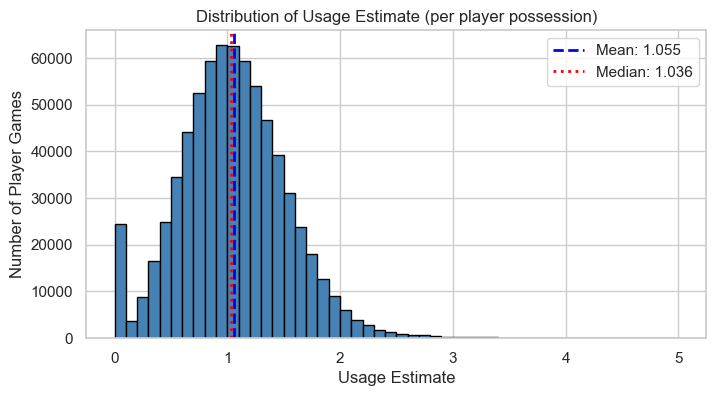

In [278]:
# Compute offensive action proxy per player
player_statistics["usage_proxy"] = (
    player_statistics["fieldGoalsAttempted"]
    + 0.44 * player_statistics["freeThrowsAttempted"]
    + player_statistics["turnovers"]
)

# Estimate usage relative to player's estimated possessions
player_statistics["usage_estimate"] = (
    player_statistics["usage_proxy"] / player_statistics["player_possessions"]
)

# Filter players with realistic usage estimate values
filtered_usage = player_statistics[player_statistics["usage_estimate"] < 5].copy()

# Compute mean and median
usage_mean = filtered_usage["usage_estimate"].mean()
usage_median = filtered_usage["usage_estimate"].median()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(filtered_usage["usage_estimate"].dropna(), bins=50, edgecolor='black', color='steelblue')
plt.axvline(usage_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {usage_mean:.3f}')
plt.axvline(usage_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {usage_median:.3f}')
plt.title('Distribution of Usage Estimate (per player possession)')
plt.xlabel('Usage Estimate')
plt.ylabel('Number of Player Games')
plt.legend()
plt.grid(True)
plt.show()

### Usage Estimate per Possession

The `usage_estimate` metric approximates how many offensive actions a player is responsible for per possession played. It combines shot attempts and turnovers into a single proxy:

$$
\text{Usage Estimate} = \frac{\text{FGA} + 0.44 \times \text{FTA} + \text{Turnovers}}{\text{Player Possessions}}
$$

This metric provides a rough but effective view of a player’s offensive workload. A value of 1.0 means the player uses one action per possession on average. Higher values indicate high-usage players who dominate offensive sequences, while lower values reflect off-ball or role players.

The distribution is slightly right-skewed, with a mean of 1.055 and a median of 1.036. This aligns with typical offensive role distributions: a few players initiate most actions, while many operate in support.

The `usage_estimate` metric was added to capture a player's offensive involvement on a per-possession basis. It reflects how frequently a player ends possessions through shot attempts or turnovers, serving as a proxy for their role in initiating or finishing plays.

This variable is particularly useful for distinguishing high-usage primary options from low-usage role players, and becomes more informative when analyzed alongside scoring efficiency metrics.

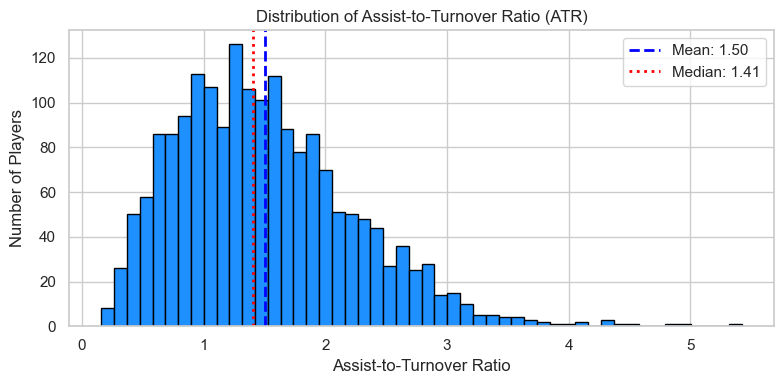

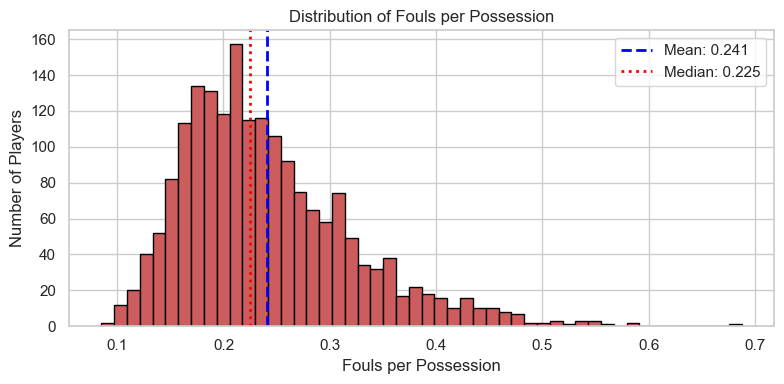

In [279]:
# Avoid division by zero for possessions
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, np.nan)

# Compute assist-turnover ratio and foul rate (row-level)
player_statistics['assist_turnover_ratio'] = (
    player_statistics['assists'] / player_statistics['turnovers'].replace(0, np.nan)
)
player_statistics['fouls_per_possession'] = (
    player_statistics['foulsPersonal'] / player_statistics['player_possessions']
)

# Aggregate stats per player
discipline_summary = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'assists': 'sum',
        'turnovers': 'sum',
        'foulsPersonal': 'sum',
        'player_possessions': 'sum',
        'gameId': 'count'
    })
    .rename(columns={'gameId': 'numGames'})
)

# Recalculate ratios after aggregation
discipline_summary['assist_turnover_ratio'] = (
    discipline_summary['assists'] / discipline_summary['turnovers'].replace(0, np.nan)
)
discipline_summary['fouls_per_possession'] = (
    discipline_summary['foulsPersonal'] / discipline_summary['player_possessions']
)

# Filter meaningful player samples
filtered_discipline = discipline_summary[
    (discipline_summary['numGames'] >= 20) &
    (discipline_summary['player_possessions'] >= 200)
]

# Plot Assist-to-Turnover Ratio
atr_mean = filtered_discipline['assist_turnover_ratio'].mean()
atr_median = filtered_discipline['assist_turnover_ratio'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_discipline['assist_turnover_ratio'].dropna(), bins=50, edgecolor='black', color='dodgerblue')
plt.axvline(atr_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {atr_mean:.2f}')
plt.axvline(atr_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {atr_median:.2f}')
plt.title('Distribution of Assist-to-Turnover Ratio (ATR)')
plt.xlabel('Assist-to-Turnover Ratio')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Fouls per Possession
fpp_mean = filtered_discipline['fouls_per_possession'].mean()
fpp_median = filtered_discipline['fouls_per_possession'].median()

plt.figure(figsize=(8, 4))
plt.hist(filtered_discipline['fouls_per_possession'].dropna(), bins=50, edgecolor='black', color='indianred')
plt.axvline(fpp_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {fpp_mean:.3f}')
plt.axvline(fpp_median, color='red', linestyle='dotted', linewidth=2, label=f'Median: {fpp_median:.3f}')
plt.title('Distribution of Fouls per Possession')
plt.xlabel('Fouls per Possession')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Assist-to-Turnover Ratio (ATR)

The `assist_turnover_ratio` measures how effectively a player distributes the ball while minimizing possession losses:

$$
\text{ATR} = \frac{\text{Assists}}{\text{Turnovers}}
$$

A higher ATR indicates efficient decision-making and ball security, particularly valuable for guards and primary playmakers. The distribution is moderately right-skewed, with a mean of 1.50 and a median of 1.41, suggesting that most players generate between 1 to 2.5 assists per turnover. This metric is widely used to evaluate a player's offensive reliability and their value in structured playmaking.

---

### Fouls per Possession (FPP)

The `fouls_per_possession` metric captures how often a player commits personal fouls per estimated possession:

$$
\text{FPP} = \frac{\text{Personal Fouls}}{\text{Player Possessions}}
$$

Fouls are a natural part of defensive play, but excessive fouling can disrupt defensive schemes and lead to penalty situations. The distribution shows a moderate right skew, with a mean of 0.241 and a median of 0.225, indicating that most players commit a foul roughly every 4–5 possessions. This metric is useful for identifying defensive discipline and potential foul-prone tendencies.


## Overview of Final Player-Level Variables

| **Category**           | **Variable Name(s)**                                           | **Description**                                                                  |
|------------------------|----------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Identity**           | `personId`, `firstName`, `lastName`, `position`               | Player identification information                                                |
| **Volume**             | `player_possessions`, `numGames`                               | Total player activity and sample size control                                    |
| **Scoring**            | `points_per_possession`, `ts_proxy`                            | Points scored per possession (raw volume) and true shooting efficiency (adjusted efficiency) |
| **Playmaking**         | `assists_per_possession`, `assist_turnover_ratio`              | Passing contribution per possession and efficiency in avoiding turnovers         |
| **Turnovers**          | `turnovers_per_possession`, `fouls_per_possession`             | Ball losses and defensive foul frequency, both normalized                        |
| **Rebounding (Total)** | `rebounds_per_possession`                                      | Overall rebounding activity                                                      |
| **Rebounding (Split)** | `off_reb_per_possession`, `def_reb_per_possession`             | Offensive and defensive rebounding impact                                        |
| **Defense**            | `steals_per_possession`, `blocks_per_possession`               | Ball pressure and rim protection contributions                                   |
| **Impact**             | `net_impact_per_possession`, `plus_minus_per_possession`       | Player’s effect on team outcomes per possession                                  |
| **Usage**              | `usage_estimate`                                               | Offensive involvement rate per possession                                        |
| **Game Context**       | `gameId`, `teamId`, `opponentTeamId`, `home`, `win`            | Game identifier, team & opponent, home/away status, and game result              |


In [280]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Replace zero possessions to avoid division errors
player_statistics['player_possessions'] = player_statistics['player_possessions'].replace(0, pd.NA)

# Aggregate per player per game (NOT per player!)
player_impact = (
    player_statistics
    .groupby(['personId', 'firstName', 'lastName', 'position', 'gameId'], as_index=False)
    .agg({
        'teamId': 'last',
        'opponentTeamId': 'last',
        'home': 'last',
        'win': 'last',  # one value per game
        'player_possessions': 'sum',
        'points': 'sum',
        'assists': 'sum',
        'turnovers': 'sum',
        'foulsPersonal': 'sum',
        'reboundsTotal': 'sum',
        'reboundsOffensive': 'sum',
        'reboundsDefensive': 'sum',
        'steals': 'sum',
        'blocks': 'sum',
        'plusMinusPoints': 'sum',
        'net_impact': 'sum',
        'fieldGoalsAttempted': 'sum',
        'freeThrowsAttempted': 'sum',
        'usage_proxy': 'sum'
    })
)

# Per-possession and derived metrics
player_impact['points_per_possession'] = player_impact['points'] / player_impact['player_possessions']
player_impact['ts_proxy'] = player_impact['points'] / (
    2 * (player_impact['fieldGoalsAttempted'] + 0.44 * player_impact['freeThrowsAttempted']))
player_impact['assists_per_possession'] = player_impact['assists'] / player_impact['player_possessions']
player_impact['assist_turnover_ratio'] = player_impact['assists'] / player_impact['turnovers'].replace(0, pd.NA)
player_impact['turnovers_per_possession'] = player_impact['turnovers'] / player_impact['player_possessions']
player_impact['fouls_per_possession'] = player_impact['foulsPersonal'] / player_impact['player_possessions']
player_impact['rebounds_per_possession'] = player_impact['reboundsTotal'] / player_impact['player_possessions']
player_impact['off_reb_per_possession'] = player_impact['reboundsOffensive'] / player_impact['player_possessions']
player_impact['def_reb_per_possession'] = player_impact['reboundsDefensive'] / player_impact['player_possessions']
player_impact['steals_per_possession'] = player_impact['steals'] / player_impact['player_possessions']
player_impact['blocks_per_possession'] = player_impact['blocks'] / player_impact['player_possessions']
player_impact['net_impact_per_possession'] = player_impact['net_impact'] / player_impact['player_possessions']
player_impact['plus_minus_per_possession'] = player_impact['plusMinusPoints'] / player_impact['player_possessions']
player_impact['usage_estimate'] = player_impact['usage_proxy'] / player_impact['player_possessions']

# Filter (minimum activity per player per game)
# → remove players with too few possessions or no shot attempts (to avoid NaN in ts_proxy)
player_impact = player_impact[
    (player_impact['player_possessions'] >= 5) &
    ((player_impact['fieldGoalsAttempted'] + 0.44 * player_impact['freeThrowsAttempted']) > 0)
].copy()

# Fix assist_turnover_ratio by setting NaN to 0 (no turnovers = safe but low risk)
player_impact['assist_turnover_ratio'] = (
    player_impact['assists'] / player_impact['turnovers'].replace(0, pd.NA)
).fillna(0).astype('float64')

# Clean up data types
player_impact["home"] = player_impact["home"].astype(bool)
player_impact["win"] = player_impact["win"].astype(bool)

# Export to CSV – now includes gameId!
player_impact.to_csv("player_impact_full.csv", index=False)
print("Export complete: 'player_impact_full.csv' with gameId per row")

Export complete: 'player_impact_full.csv' with gameId per row


In [281]:
columns_to_drop = [
    'points', 'assists', 'turnovers', 'foulsPersonal',
    'reboundsTotal', 'reboundsOffensive', 'reboundsDefensive',
    'steals', 'blocks',
    'plusMinusPoints', 'net_impact',
    'fieldGoalsAttempted', 'freeThrowsAttempted',
    'usage_proxy'
]

player_impact.drop(columns=columns_to_drop, inplace=True)

player_impact.to_csv("player_impact.csv", index=False)


In [282]:
print("Detailed column overview\n")

for col in player_impact.columns:
    dtype = player_impact[col].dtype
    missing = player_impact[col].isnull().sum()

    if dtype == 'object':
        example_values = player_impact[col].dropna().unique()[:3]
        examples = f"Examples: {str(list(example_values))}"
        print(f"| {str(col):<30} | {str(dtype):>15} | {examples:<80} | Missing: {missing:>10} |")
    else:
        min_val = player_impact[col].min()
        max_val = player_impact[col].max()
        r = f"Range: {min_val} to {max_val}"
        print(f"| {str(col):<30} | {str(dtype):>15} | {r:<80} | Missing: {missing:>10} |")


Detailed column overview

| personId                       |           int64 | Range: 2 to 1642419                                                              | Missing:          0 |
| firstName                      |          object | Examples: ['Byron', 'Grant', 'Dan']                                              | Missing:          0 |
| lastName                       |          object | Examples: ['Scott', 'Long', 'Schayes']                                           | Missing:          0 |
| position                       |          object | Examples: ['C', 'F', 'G']                                                        | Missing:          0 |
| gameId                         |           int64 | Range: 20000001 to 29901189                                                      | Missing:          0 |
| teamId                         |           int64 | Range: 1610612737 to 1610612766                                                  | Missing:          0 |
| opponentTeamId          

# Identify high-impact players based on performance indicators

## Player Impact Analysis: Relative Impact within Team Context

## Objective

To quantify and identify high-impact players while controlling for team and game context.  
We evaluate each player's performance relative to the average performance of their team in the same game, using the `plus_minus_per_possession` metric.

## Motivation

Traditional plus-minus metrics can be misleading due to:
- Varying teammate quality
- Game dynamics and opponent strength
- Garbage time effects

By comparing a player's performance against the overall team average in the same game, we reduce external noise and gain a cleaner signal of individual contribution.

## Method

1. For each game and team, compute the team average plus-minus per possession (including the player).
2. Subtract this average from the player’s own value to get a `relative_impact` score.
3. Aggregate these scores across games for each player.
4. Apply minimum thresholds (e.g., number of games, average possessions, usage) to ensure robustness.
5. Rank players by their average relative impact to highlight consistent high contributors.

Since the team average includes the player, this method is slightly more conservative than a "leave-one-out" approach but allows for much faster computation.

## Output

- A summary DataFrame per player with:
  - `relative_impact_mean` – average relative impact across games
  - `relative_impact_std` – variability of impact
  - `num_games` – robustness filter
  - `avg_possessions`, `avg_usage`, `avg_net_impact` – context metrics
- A ranked list of the top 20 highest-impact players (min. 50 games, ≥10 possessions, usage ≥ 0.5)

## Use Case

The resulting metric can be:
- Used for objective player ranking and scouting
- Incorporated into a predictive model of match outcomes
- Cross-checked against salary or minutes to detect undervalued contributors


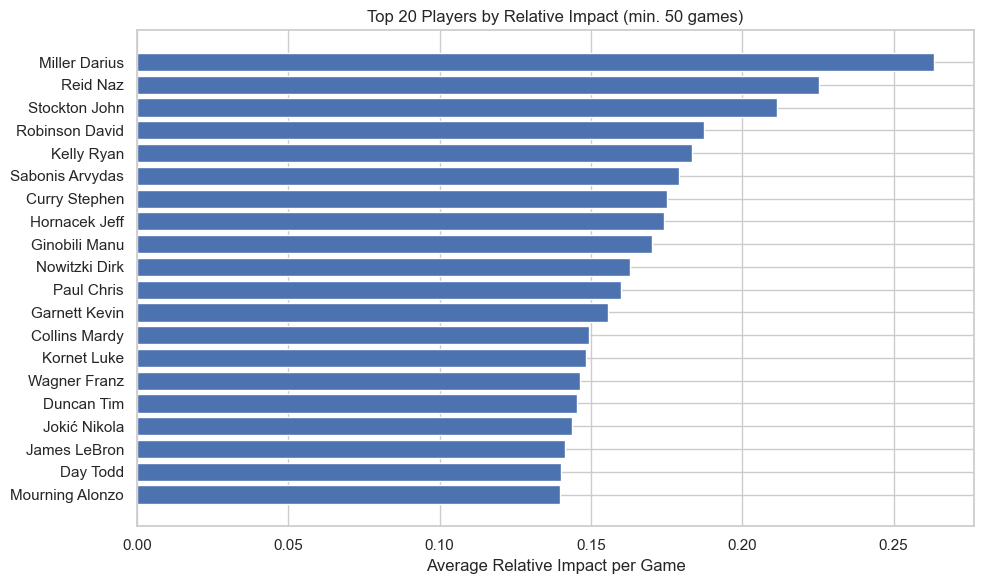

In [283]:
# Compute inclusive team average per game/team
team_avg_pm = player_impact.groupby(['gameId', 'teamId'])['plus_minus_per_possession'].transform('mean')

# Subtract team average from player's own value
player_impact['relative_impact'] = player_impact['plus_minus_per_possession'] - team_avg_pm

# Aggregate by player
relative_impact_summary = (
    player_impact
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'relative_impact': ['mean', 'std', 'count'],
        'plus_minus_per_possession': 'mean',
        'net_impact_per_possession': 'mean',
        'usage_estimate': 'mean',
        'player_possessions': 'mean'
    })
)

# Rename columns
relative_impact_summary.columns = [
    'personId', 'firstName', 'lastName',
    'relative_impact_mean', 'relative_impact_std', 'num_games',
    'avg_plus_minus', 'avg_net_impact', 'avg_usage',
    'avg_possessions'
]

# Filter more strictly
relative_impact_summary = relative_impact_summary[
    (relative_impact_summary['num_games'] >= 50) &
    (relative_impact_summary['avg_possessions'] >= 10) &
    (relative_impact_summary['avg_usage'] >= 0.5)
]

# Sort and view top 20 highest-impact players
top_players = relative_impact_summary.sort_values(by='relative_impact_mean', ascending=False).head(20)

# Plot results
top = top_players.sort_values(by='relative_impact_mean', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top['lastName'] + ' ' + top['firstName'], top['relative_impact_mean'])
plt.xlabel('Average Relative Impact per Game')
plt.title('Top 20 Players by Relative Impact (min. 50 games)')
plt.tight_layout()
plt.show()

Current ranking overview:

- Per player

- By average relative impact

- Filtered by minimum number of games, average usage, and average possessions

## Composite Impact Efficiency Score

## Introduction  
The Composite Impact Efficiency Score combines a player’s relative impact with their playing role and consistency, offering a single metric that highlights truly impactful contributors rather than occasional standouts.

---

## Definition  

We define the score as:

**efficiency_score = relative_impact_mean × log1p(avg_usage) × sqrt(num_games)**

- **relative_impact_mean**  
  Shows how much better (or worse) a player performs compared to their teammates on average, based on plus-minus per possession.

- **log1p(avg_usage)**  
  Gives more weight to players who are involved in many possessions, but gently slows down the effect for extremely high usage to keep things fair.

- **sqrt(num_games)**  
  Rewards players who perform well over many games, but in a balanced way —> so long careers help, but don’t automatically dominate the rankings.

In [284]:
# Compute inclusive team average per game/team
team_avg_pm = player_impact.groupby(['gameId', 'teamId'])['plus_minus_per_possession'] \
                           .transform('mean')

# Subtract team average from player's own value
player_impact['relative_impact'] = player_impact['plus_minus_per_possession'] - team_avg_pm

# Aggregate by player
relative_impact_summary = (
    player_impact
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'relative_impact': ['mean', 'std', 'count'],
        'plus_minus_per_possession': 'mean',
        'net_impact_per_possession': 'mean',
        'usage_estimate': 'mean',
        'player_possessions': 'mean'
    })
)

# Flatten column names
relative_impact_summary.columns = [
    'personId', 'firstName', 'lastName',
    'relative_impact_mean', 'relative_impact_std', 'num_games',
    'avg_plus_minus', 'avg_net_impact', 'avg_usage',
    'avg_possessions'
]

# Apply strict filters
relative_impact_summary = relative_impact_summary[
    (relative_impact_summary['num_games'] >= 50) &
    (relative_impact_summary['avg_possessions'] >= 10) &
    (relative_impact_summary['avg_usage'] >= 0.5)
]


# Compute the Composite Impact Efficiency Score
relative_impact_summary['efficiency_score'] = (
    relative_impact_summary['relative_impact_mean']
    * np.log1p(relative_impact_summary['avg_usage'])
    * np.sqrt(relative_impact_summary['num_games'])
)

# Sort by efficiency_score and select top 20
top_efficiency = (
    relative_impact_summary
    .sort_values(by='efficiency_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Display as a neat DataFrame
display(top_efficiency[[
    'firstName', 'lastName',
    'relative_impact_mean', 'avg_usage',
    'num_games', 'efficiency_score'
]])

,firstName,lastName,relative_impact_mean,avg_usage,num_games,efficiency_score
0,LeBron,James,0.141335,1.743830,1559,5.632690
1,Dirk,Nowitzki,0.162770,1.467745,1463,5.623810
2,Stephen,Curry,0.175055,1.593251,1017,5.319715
3,Kevin,Garnett,0.155451,1.374511,1363,4.963106
4,Tim,Duncan,0.145362,1.488393,1382,4.926385
5,Chris,Paul,0.159978,1.255821,1310,4.710442
6,Manu,Ginobili,0.170243,1.347375,925,4.418145
7,Shaquille,O'Neal,0.136841,1.629762,900,3.969333
8,John,Stockton,0.211301,1.082110,522,3.540511
9,Nikola,Jokić,0.143644,1.482284,732,3.533392


In [285]:
# 2 Variante: without usage

# Compute impact_volume_score = relative_impact_mean * sqrt(num_games)
relative_impact_summary['impact_volume_score'] = (
    relative_impact_summary['relative_impact_mean']
    * np.sqrt(relative_impact_summary['num_games'])
)

# Sort and take top 20
top_volume = (
    relative_impact_summary
    .sort_values(by='impact_volume_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Display as a nice table
display(top_volume[[
    'firstName', 'lastName',
    'relative_impact_mean', 'num_games',
    'impact_volume_score'
]])

,firstName,lastName,relative_impact_mean,num_games,impact_volume_score
0,Dirk,Nowitzki,0.162770,1463,6.225816
1,Chris,Paul,0.159978,1310,5.790241
2,Kevin,Garnett,0.155451,1363,5.739078
3,Stephen,Curry,0.175055,1017,5.582585
4,LeBron,James,0.141335,1559,5.580486
5,Tim,Duncan,0.145362,1382,5.403888
6,Manu,Ginobili,0.170243,925,5.177730
7,John,Stockton,0.211301,522,4.827651
8,Shaquille,O'Neal,0.136841,900,4.105244
9,Nikola,Jokić,0.143644,732,3.886355


### Variant 2: Impact Volume Score (without usage weighting)

In this second approach, we ranked players solely based on how much impact they consistently delivered across games —> without considering how much of the offense they used. This gives us a clearer view of players who were valuable over long periods, regardless of role size.

---

### Variant 3: Z-Score-Based Impact (Standardized Performance)

Next, we shift focus to a statistical measure of impact.

Instead of comparing a player's performance to the team average in raw terms, we calculate how many standard deviations above or below the team average they performed in each game.

This Z-score-based method tells us:
- Who consistently stood out within their team, even in balanced lineups.
- Which players delivered exceptional performances relative to their teammates, not just in absolute terms.

It’s useful for detecting impact outliers and contextualizing players who may not have had high volume but consistently exceeded expectations.


In [286]:
# Calculate team mean and standard deviation of plus-minus per possession for each game/team
team_stats = (
    player_impact
    .groupby(['gameId', 'teamId'])['plus_minus_per_possession']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'team_pm_mean', 'std': 'team_pm_std'})
    .reset_index()
)

# Merge these team-level stats back into the player_impact DataFrame
player_impact = player_impact.merge(
    team_stats,
    on=['gameId', 'teamId'],
    how='left'
)

# Compute each player's Z-score relative to their team's distribution in that game
player_impact['relative_impact_z'] = (
    (player_impact['plus_minus_per_possession'] - player_impact['team_pm_mean'])
    / player_impact['team_pm_std']
)

# Aggregate Z-score metrics per player
zscore_summary = (
    player_impact
    .groupby(['personId', 'firstName', 'lastName'], as_index=False)
    .agg({
        'relative_impact_z': ['mean', 'std', 'count'],
        'player_possessions': 'mean'
    })
)

# Flatten the hierarchical column index
zscore_summary.columns = [
    'personId', 'firstName', 'lastName',
    'zscore_mean', 'zscore_std', 'num_games',
    'avg_possessions'
]

# Filter for robustness (e.g., minimum 50 games and at least 10 possessions per game on average)
zscore_summary = zscore_summary[
    (zscore_summary['num_games'] >= 50) &
    (zscore_summary['avg_possessions'] >= 10)
]

# Sort and display the top 20 players by average Z-score
top_zscore = zscore_summary.sort_values('zscore_mean', ascending=False).head(20)
display(top_zscore[['firstName', 'lastName', 'zscore_mean', 'num_games', 'avg_possessions']])

,firstName,lastName,zscore_mean,num_games,avg_possessions
1994,Naz,Reid,0.342639,73,12.432635
1464,Darius,Miller,0.300465,63,10.032546
280,Arvydas,Sabonis,0.227689,353,10.095382
1625,Nikola,Jokić,0.223646,732,13.424709
160,John,Stockton,0.219660,522,11.644656
300,David,Robinson,0.218653,425,11.729567
1839,Luke,Kornet,0.217786,56,10.971675
1232,Stephen,Curry,0.212641,1017,14.454588
54,Todd,Day,0.203704,124,10.735052
2097,Franz,Wagner,0.203398,287,13.637217


In [287]:
# Merge impact_volume_score into the Z-score summary
zscore_merged = (
    zscore_summary
    .merge(
        relative_impact_summary[['personId', 'impact_volume_score']],
        on='personId',
        how='left'
    )
)

# Raise the minimum games threshold to 100 for robustness
zscore_merged = zscore_merged[zscore_merged['num_games'] >= 100]

# Consistency filter: keep players with high average Z-score and low variability
mean_threshold = zscore_merged['zscore_mean'].quantile(0.75)
std_threshold  = zscore_merged['zscore_std'].quantile(0.25)

consistent_outliers = zscore_merged[
    (zscore_merged['zscore_mean'] >= mean_threshold) &
    (zscore_merged['zscore_std']  <= std_threshold)
].copy()

# Combine volume and Z-score into a single composite
consistent_outliers['volume_zscore_score'] = (
    consistent_outliers['impact_volume_score']
    * consistent_outliers['zscore_mean']
)

# Sort by the new composite and display top 20
top_combined = (
    consistent_outliers
    .sort_values(by='volume_zscore_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_combined[[
    'firstName', 'lastName',
    'zscore_mean', 'zscore_std',
    'impact_volume_score',
    'volume_zscore_score',
    'num_games'
]])

,firstName,lastName,zscore_mean,zscore_std,impact_volume_score,volume_zscore_score,num_games
0,Stephen,Curry,0.212641,0.733439,5.582585,1.187089,1017
1,Dirk,Nowitzki,0.185387,0.747750,6.225816,1.154184,1463
2,Kevin,Garnett,0.184895,0.726938,5.739078,1.061129,1363
3,John,Stockton,0.219660,0.813168,4.827651,1.060441,522
4,Chris,Paul,0.179298,0.759424,5.790241,1.038181,1310
5,LeBron,James,0.157781,0.710208,5.580486,0.880494,1559
6,Tim,Duncan,0.160283,0.707621,5.403888,0.866152,1382
7,David,Robinson,0.218653,0.793032,3.858624,0.843698,425
8,Shaquille,O'Neal,0.162646,0.762454,4.105244,0.667700,900
9,Jeff,Hornacek,0.168945,0.797915,2.952327,0.498781,287


In [288]:
# Prepare export table from top_combined
top_10_export = top_combined.copy()
top_10_export.insert(0, 'Rank', range(1, len(top_10_export) + 1))
top_10_export['Player'] = top_10_export['firstName'] + ' ' + top_10_export['lastName']
top_10_export = top_10_export[[
    'Rank', 'Player', 'zscore_mean', 'zscore_std',
    'impact_volume_score', 'volume_zscore_score', 'num_games'
]].rename(columns={
    'zscore_mean': 'Avg. Z-Score',
    'zscore_std': 'Z-Score Std',
    'impact_volume_score': 'Impact Volume',
    'volume_zscore_score': 'Composite Score',
    'num_games': 'Games Played'
})

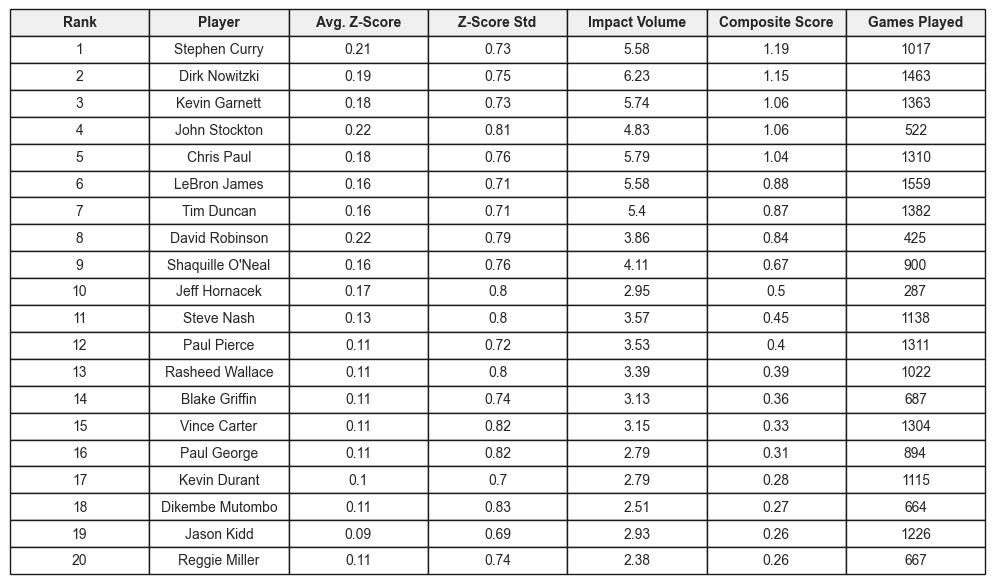

In [289]:
# Round numerical columns for cleaner display
top_10_export_rounded = top_10_export.copy()
top_10_export_rounded[['Avg. Z-Score', 'Z-Score Std', 'Impact Volume', 'Composite Score']] = \
    top_10_export_rounded[['Avg. Z-Score', 'Z-Score Std', 'Impact Volume', 'Composite Score']].round(2)

# Create figure and hide axes
fig, ax = plt.subplots(figsize=(10, 6))  # Wider layout for readability
ax.axis('off')  # Hide axes

# Create the visual table
table = ax.table(
    cellText=top_10_export_rounded.values,
    colLabels=top_10_export_rounded.columns,
    cellLoc='center',
    loc='center'
)

# Format the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.6)  # Adjust cell width and height

# Highlight header row (row 0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')       # Make header bold
        cell.set_facecolor('#f0f0f0')            # Light gray background

# Show final table
plt.tight_layout()
plt.show()

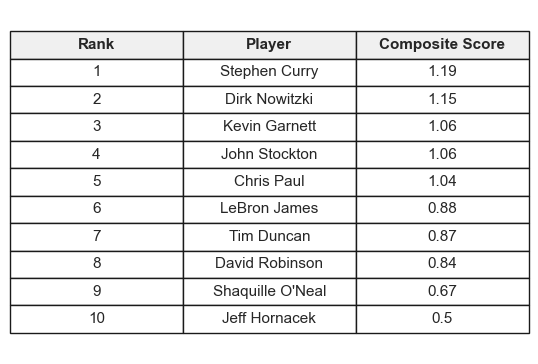

In [290]:
# Filter only the top 10 entries
top_10_minimal = top_10_export[['Rank', 'Player', 'Composite Score']].head(10).copy()
top_10_minimal['Composite Score'] = top_10_minimal['Composite Score'].round(2)

# Create figure and remove axes
fig, ax = plt.subplots(figsize=(5.5, 3.8))  # Compact size for slide
ax.axis('off')  # No axes shown

# Create styled table
table = ax.table(
    cellText=top_10_minimal.values,
    colLabels=top_10_minimal.columns,
    cellLoc='center',
    loc='center'
)

# Table formatting
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 1.4)  # Adjust width/height for spacing

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0')  # Light gray background

# Render table
plt.tight_layout()
plt.show()


### 1. Average Z-Score

This reflects **how much better (or worse)** a player's performance was compared to their team's average.

$$
\text{Avg. Z-Score} = \frac{\text{Performance} - \text{Team Mean}}{\text{Team Std. Dev.}}
$$

A value of 0 means team-average, while +0.2 means consistently above team level.

---

### 2. Impact Volume

This reflects **how often** the player contributed meaningfully — based on their possessions and effectiveness.

$$
\text{Impact Volume} = \text{Player Possessions} \times \left| \text{Net Impact per Possession} \right|
$$

So a player who plays often and has high impact per possession gets a higher volume score.

---

### 3. Composite Score

The final score combines **impact** and **consistency**:

$$
\text{Composite Score} = \text{Avg. Z-Score} \times \text{Impact Volume}
$$


### Final Composite Ranking: Consistent and High-Impact Players

This final table showcases players who combined statistical dominance within their teams (high Z-scores), consistency (low variability), and sustained performance over time (many games and strong volume impact).

We filtered for:
- A minimum of 100 games to ensure reliability
- Players in the top 25% of average Z-score
- Players in the bottom 25% of Z-score standard deviation
- A final composite score: `volume_zscore_score = impact_volume_score × zscore_mean`

This score highlights players who were not just good, but consistently better than their teammates —> and did so across many games.

- **Stephen Curry** ranks #1: a rare combination of elite performance, usage, and consistency, even among other stars.
- **Dirk Nowitzki** and **Kevin Garnett** confirm their reputations as long-term difference-makers with consistently high impact.
- **John Stockton** and **David Robinson**, though retired for years, stand out as top outliers —> often performing well above their teammates.
- **LeBron James** and **Tim Duncan** appear slightly lower than expected —> reflecting that their greatness often came as part of strong overall teammates, not via statistical dominance alone.

This ranking offers a nuanced, data-driven alternative to traditional all-time lists. Instead of favoring flashy stats or awards, it highlights:
- Players who consistently outperformed their teammates
- Longevity without sacrificing efficiency
- Hidden gems (like Jeff Hornacek or Rasheed Wallace) whose value may be underappreciated
but keep in mind that we work with regular season data -> regular season stars :)


---

### Structural Impact at the Team Level: Do These Players Actually Drive Wins?

After identifying the most consistently dominant individuals, we now turn to a broader question:  
Do teams win more often when they include structurally high-impact players in their lineup?

To answer this, we define "high-impact" players dynamically —> not just based on raw stats or fame, but through:
- Season-long Z-score averages in the top 10% of all players
- A minimum of 50 games played to ensure consistency and relevance

We then trace how many of these players appeared in each game, and whether their presence correlates with winning.  
The following analysis aggregates this player-level information to the team-game level, building the foundation for a statistical test of impact.


In [291]:
# First, inspect the distribution of season-long mean Z-scores
print("Z-score mean distribution:")
print(zscore_summary['zscore_mean'].describe())

# important quantiles
for q in [0.5, 0.75, 0.9, 0.95]:
    print(f"{int(q*100)}th percentile:", zscore_summary['zscore_mean'].quantile(q))


# Choose a dynamic threshold: e.g. top 10% of players by zscore_mean
min_games = 50             # keep your robustness filter
quantile = 0.90            # top 10%

# compute the 90th percentile threshold
z_thresh = zscore_summary['zscore_mean'].quantile(quantile)
print(f"Using zscore_mean >= {z_thresh:.3f} as high-impact cutoff")

# Select players above that threshold
high_impact_dyn = (
    zscore_summary
    .loc[
        (zscore_summary['num_games'] >= min_games) &
        (zscore_summary['zscore_mean'] >= z_thresh),
        ['personId']
    ]
    .assign(is_high_impact=True)
)

print("Dynamic high-impact players count:", len(high_impact_dyn))


# Merge the flag back into your per-game DataFrame
player_impact_flagged = (
    player_impact
    .merge(high_impact_dyn, on='personId', how='left')
    .assign(
        is_high_impact=lambda df: df['is_high_impact'].fillna(False).astype(bool)
    )
)

# Aggregate to team-game level
team_game_stats = (
    player_impact_flagged
    .groupby(['gameId', 'teamId'], as_index=False)
    .agg(
        team_win=('win', 'first'),
        num_high_impact=('is_high_impact', 'sum')
    )
)

# Quick check: average number of these players in wins vs. losses
print(team_game_stats.groupby('team_win')['num_high_impact'].mean())

# Correlation
corr = team_game_stats[['num_high_impact', 'team_win']] \
       .corr().loc['num_high_impact', 'team_win']
print(f"Correlation (high-impact count vs. win): {corr:.3f}")

Z-score mean distribution:
count    820.000000
mean      -0.010980
std        0.088424
min       -0.402083
25%       -0.072842
50%       -0.008459
75%        0.045896
max        0.342639
Name: zscore_mean, dtype: float64
50th percentile: -0.008459402764210183
75th percentile: 0.04589553855354592
90th percentile: 0.09433938487304962
95th percentile: 0.13354551183702595
Using zscore_mean >= 0.094 as high-impact cutoff
Dynamic high-impact players count: 82
team_win
False    0.520780
True     0.690866
Name: num_high_impact, dtype: float64
Correlation (high-impact count vs. win): 0.118


In [292]:
# Prepare data
X = sm.add_constant(team_game_stats['num_high_impact'])  # add intercept
y = team_game_stats['team_win'].astype(int)             # convert bool to int

# Fit logit model
logit_model = sm.Logit(y, X).fit(disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:               team_win   No. Observations:                68624
Model:                          Logit   Df Residuals:                    68622
Method:                           MLE   Df Model:                            1
Date:                Sun, 18 May 2025   Pseudo R-squ.:                 0.01013
Time:                        16:45:09   Log-Likelihood:                -47085.
converged:                       True   LL-Null:                       -47567.
Covariance Type:            nonrobust   LLR p-value:                1.332e-211
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.2006      0.010    -19.965      0.000      -0.220      -0.181
num_high_impact     0.3330      0.011     30.675      0.000       0.312       0.354


In [293]:
# compute odds ratio for one additional high-impact player
coef = 0.3330
odds_ratio = np.exp(coef)
print(f"Odds Ratio per high-impact player: {odds_ratio:.2f}")
# => etwa 1.39, also ~39 % höhere Odds pro zusätzlichem Spieler

Odds Ratio per high-impact player: 1.40


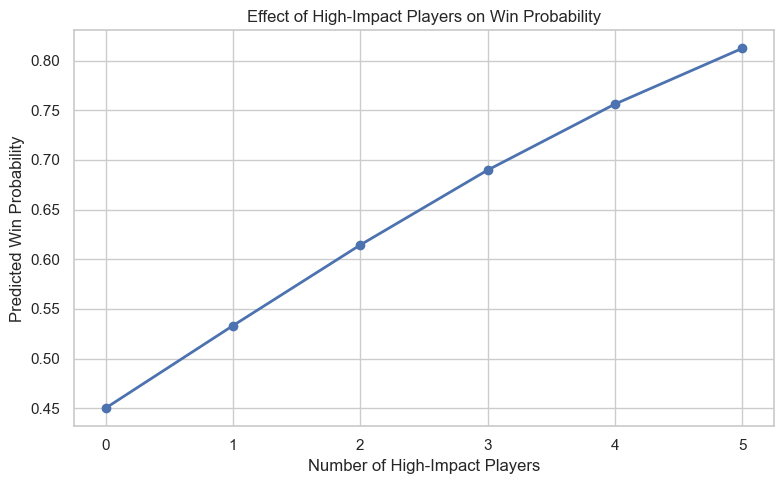

,High-Impact Players,Win Odds,Win Probability
0,0,0.818240,0.450017
1,1,1.141565,0.533052
2,2,1.592651,0.614294
3,3,2.221983,0.689632
4,4,3.099993,0.756097
5,5,4.324947,0.812205


In [294]:
# Coefficients from the fitted logistic regression model
intercept = -0.2006
coef = 0.3330

# Create a DataFrame for high-impact player counts from 0 to 5
df_plot = pd.DataFrame({'num_high_impact': range(6)})

# Calculate log-odds, odds, and predicted win probability
df_plot['log_odds'] = intercept + coef * df_plot['num_high_impact']
df_plot['odds'] = np.exp(df_plot['log_odds'])
df_plot['win_prob'] = df_plot['odds'] / (1 + df_plot['odds'])

# Plot the predicted win probability curve
plt.figure(figsize=(8, 5))
plt.plot(df_plot['num_high_impact'], df_plot['win_prob'], marker='o', linestyle='-', linewidth=2)
plt.xticks(df_plot['num_high_impact'])
plt.xlabel('Number of High-Impact Players')
plt.ylabel('Predicted Win Probability')
plt.title('Effect of High-Impact Players on Win Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

# Show the corresponding values as a table
display(df_plot[['num_high_impact', 'odds', 'win_prob']].rename(columns={
    'num_high_impact': 'High-Impact Players',
    'odds': 'Win Odds',
    'win_prob': 'Win Probability'
}))

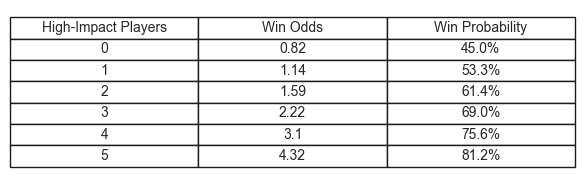

In [295]:
# Round values for cleaner display
df_export = df_plot[['num_high_impact', 'odds', 'win_prob']].copy()
df_export.columns = ['High-Impact Players', 'Win Odds', 'Win Probability']
df_export['Win Odds'] = df_export['Win Odds'].round(2)
df_export['Win Probability'] = (df_export['Win Probability'] * 100).round(1).astype(str) + '%'

# Plot the table as an image
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')  # hide axes
table = ax.table(cellText=df_export.values,
                 colLabels=df_export.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)  # adjust size

plt.tight_layout()
plt.savefig("win_probability_table.png", dpi=300, bbox_inches='tight')  # high-res image for slides
plt.show()

We investigated whether teams win more often when they have structurally strong rosters, defined as including players with season-average Z-scores in the top 10 percent and at least 50 games played. The results show a statistically significant relationship between the number of such players and the likelihood of winning. Each additional high-impact player increases a team's odds of winning by approximately 40 percent, and teams with five high-impact players have a predicted win probability of over 80 percent. However, the overall explanatory power of the model is low (pseudo R² ≈ 1%), and the actual difference in the number of high-impact players between winning and losing teams is modest —> on average, winning teams had only about 0.17 more such players than losing teams. This suggests that while structurally strong players do contribute to team success, many other factors are also at play. Furthermore, the results depend on how we define high-impact players, which makes the analysis sensitive to threshold choices.

# Explore correlations between individual stats and team success

In [296]:
# Load CSV into player_impact
player_impact = pd.read_csv(os.path.join(DATA_PATH, "player_impact.csv"))

# Compute team mean and standard deviation of plus-minus per possession
team_stats = (
    player_impact
    .groupby(['gameId', 'teamId'])
    .agg(
        team_pm_mean=('plus_minus_per_possession', 'mean'),
        team_pm_std =('plus_minus_per_possession', 'std')
    )
    .reset_index()
)

# Inspect columns to confirm names
print(team_stats.columns)  # should show ['gameId','teamId','team_pm_mean','team_pm_std']

# Merge the named-aggregation results back into player_impact
player_impact = player_impact.merge(
    team_stats,
    on=['gameId', 'teamId'],
    how='left'
)

# Compute the Z-score now that the columns exist
player_impact['relative_impact_z'] = (
    (player_impact['plus_minus_per_possession'] - player_impact['team_pm_mean'])
    / player_impact['team_pm_std']
)

# Optional cleanup
player_impact.drop(columns=['team_pm_mean', 'team_pm_std'], inplace=True)

# Export if needed
player_impact.to_csv("player_impact_with_z.csv", index=False)
print("Export complete: 'player_impact_with_z.csv' now includes relative_impact_z.")

Index(['gameId', 'teamId', 'team_pm_mean', 'team_pm_std'], dtype='object')
Export complete: 'player_impact_with_z.csv' now includes relative_impact_z.


In [297]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load the updated player_impact (with relative_impact_z)
player_impact = pd.read_csv("player_impact_with_z.csv")
player_impact['win'] = player_impact['win'].astype(bool)

# Select only the numeric features to test
features = [
    'points_per_possession',
    'ts_proxy',
    'assists_per_possession',
    'turnovers_per_possession',
    'fouls_per_possession',
    'off_reb_per_possession',
    'def_reb_per_possession',
    'steals_per_possession',
    'blocks_per_possession',
    'net_impact_per_possession',
    'plus_minus_per_possession',
    'usage_estimate',
    'relative_impact_z'
]

# Aggregate to team-game level (mean per team per game)
team_game_stats = (
    player_impact
    .groupby(['gameId', 'teamId', 'win'], as_index=False)[features]
    .mean()
)

# Drop rows where relative_impact_z is NaN (e.g. due to zero std)
team_game_stats = team_game_stats.dropna(subset=['relative_impact_z'])

# Define VIF helper functions
def calculate_vif(df):
    X = df.copy()
    X['Intercept'] = 1.0  # Required by statsmodels
    vif_rows = []
    for i, col in enumerate(X.columns):
        if col == 'Intercept':
            continue
        vif = variance_inflation_factor(X.values, i)
        vif_rows.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

def drop_high_vif(df, thresh=15.0):
    df_work = df.copy()
    while True:
        vif_df = calculate_vif(df_work)
        max_vif = vif_df['VIF'].max()
        if max_vif <= thresh:
            break
        drop_col = vif_df.iloc[0]['feature']
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        df_work = df_work.drop(columns=[drop_col])
    return df_work

# Compute initial VIFs
initial_vif = calculate_vif(team_game_stats[features])
print("Initial VIFs:\n", initial_vif)

# Iteratively drop high-VIF features
reduced = drop_high_vif(team_game_stats[features], thresh=15.0)

# Final VIFs after reduction
final_vif = calculate_vif(reduced)
print("\nReduced features:", reduced.columns.tolist())
print("Final VIFs:\n", final_vif)

Initial VIFs:
                       feature       VIF
2      assists_per_possession       inf
4        fouls_per_possession       inf
3    turnovers_per_possession       inf
7       steals_per_possession       inf
8       blocks_per_possession       inf
10  plus_minus_per_possession       inf
9   net_impact_per_possession       inf
0       points_per_possession  9.824483
1                    ts_proxy  5.819858
11             usage_estimate  4.554502
5      off_reb_per_possession  1.576068
6      def_reb_per_possession  1.424549
12          relative_impact_z  1.000420
Dropping assists_per_possession (VIF=inf)
Dropping net_impact_per_possession (VIF=262.9)

Reduced features: ['points_per_possession', 'ts_proxy', 'turnovers_per_possession', 'fouls_per_possession', 'off_reb_per_possession', 'def_reb_per_possession', 'steals_per_possession', 'blocks_per_possession', 'plus_minus_per_possession', 'usage_estimate', 'relative_impact_z']
Final VIFs:
                       feature       VIF
0   

## Feature Selection Using Variance Inflation Factor (VIF)

To ensure that our model is not affected by multicollinearity (strong linear dependencies between predictors), we applied a Variance Inflation Factor (VIF) analysis to the player-level statistics aggregated at the team-game level.

### Method

- We selected 13 core performance indicators per possession, including shooting efficiency, turnovers, rebounds, and an advanced metric (`relative_impact_z`) representing a player's standardized impact compared to teammates.
- These metrics were averaged across players per team per game.
- We then applied the VIF procedure iteratively, removing variables with extremely high multicollinearity (VIF ≥ ∞ or VIF > 15).

### Outcome

The following two variables were removed:
- `assists_per_possession` (VIF = ∞): perfectly collinear with other passing-related stats
- `net_impact_per_possession` (VIF ≈ 263): highly correlated with `plus_minus_per_possession`

### Final Feature Set (All VIFs ≤ 10)

| Feature                      | VIF  |
|-----------------------------|------|
| `points_per_possession`     | 9.59 |
| `ts_proxy`                  | 5.82 |
| `usage_estimate`            | 4.55 |
| `plus_minus_per_possession` | 2.17 |
| `turnovers_per_possession`  | 1.80 |
| `off_reb_per_possession`    | 1.56 |
| `def_reb_per_possession`    | 1.42 |
| `steals_per_possession`     | 1.19 |
| `fouls_per_possession`      | 1.08 |
| `blocks_per_possession`     | 1.05 |
| `relative_impact_z`         | 1.00 |

These features are now ready to be used in predictive modeling (e.g., win/loss classification) without strong risk of redundancy or unstable coefficients.


### Aggregation Method: Weighted Averages for Sensitive Metrics

To compute meaningful team-level features from player-level statistics, we distinguish between two types of metrics during aggregation:

#### 1. Uniformly Comparable Metrics (Per-Possession)
Most features —> such as `points_per_possession`, `ts_proxy`, or `steals_per_possession`—are already normalized per possession and are thus directly comparable across players, regardless of minutes played.  
For these, we use simple arithmetic mean across all players from the same team in a game.

#### 2. Usage- and Impact-Sensitive Metrics

Metrics like `usage_estimate`, `plus_minus_per_possession`, and `relative_impact_z` are more sensitive to the amount of time and involvement a player had in a game.  
Here, we apply a weighted average using the number of possessions (`player_possessions`) as weights:

$$
\text{Weighted Mean} = \frac{\sum_{i=1}^{n} x_i \cdot w_i}{\sum_{i=1}^{n} w_i}
$$

Where:

- $x_i$ = player’s metric value  
- $w_i$ = number of possessions the player was involved in

This approach ensures that highly involved players influence team-level values more strongly, which improves stability and relevance of aggregated features.

#### Why this matters
- Gives more influence to core players who contributed more during the game.
- Reduces bias from bench players with small sample sizes.
- Helps stabilize metrics like `relative_impact_z`, which depend on team context.

#### Result
By combining weighted and unweighted aggregation, we ensure that the final team-level dataset better reflects the true collective impact of a team in each game, and is robust for predictive modeling or correlation analysis.


In [298]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load the data
player_impact = pd.read_csv("player_impact_with_z.csv")
player_impact['win'] = player_impact['win'].astype(bool)

# Define relevant columns
base_cols = ['gameId', 'teamId', 'win', 'player_possessions']
mean_features = [
    'points_per_possession',
    'ts_proxy',
    'turnovers_per_possession',
    'fouls_per_possession',
    'off_reb_per_possession',
    'def_reb_per_possession',
    'steals_per_possession',
    'blocks_per_possession',
]
weighted_features = [
    'usage_estimate',
    'plus_minus_per_possession',
    'relative_impact_z',
]

all_cols = base_cols + mean_features + weighted_features

# Drop rows with missing values in relevant features
df = player_impact[all_cols].dropna()

# Group by gameId + teamId + win
grouped = df.groupby(['gameId', 'teamId', 'win'])

# Compute unweighted means
mean_df = grouped[mean_features].mean()

# Compute weighted means for selected features
def weighted_avg(x, value_col):
    weights = x['player_possessions']
    values = x[value_col]
    return np.average(values, weights=weights)

weighted_df = grouped.apply(
    lambda g: pd.Series({
        col: weighted_avg(g, col) for col in weighted_features
    })
)

# Combine both
team_game_features = pd.concat([mean_df, weighted_df], axis=1).reset_index()

# Export to CSV with final name
team_game_features.to_csv("team_game_features_vif_ready.csv", index=False)
print("Export complete: 'team_game_features_vif_ready.csv'")

Export complete: 'team_game_features_vif_ready.csv'


Correlation of features with 'win':
win                          1.000000
plus_minus_per_possession    0.765545
points_per_possession        0.394524
ts_proxy                     0.380771
def_reb_per_possession       0.315122
blocks_per_possession        0.156096
steals_per_possession        0.142762
relative_impact_z            0.099032
usage_estimate              -0.005450
off_reb_per_possession      -0.023699
fouls_per_possession        -0.099153
turnovers_per_possession    -0.115050
Name: win, dtype: float64

Strong correlations (|r| > 0.2):
win                          1.000000
plus_minus_per_possession    0.765545
points_per_possession        0.394524
ts_proxy                     0.380771
def_reb_per_possession       0.315122
Name: win, dtype: float64


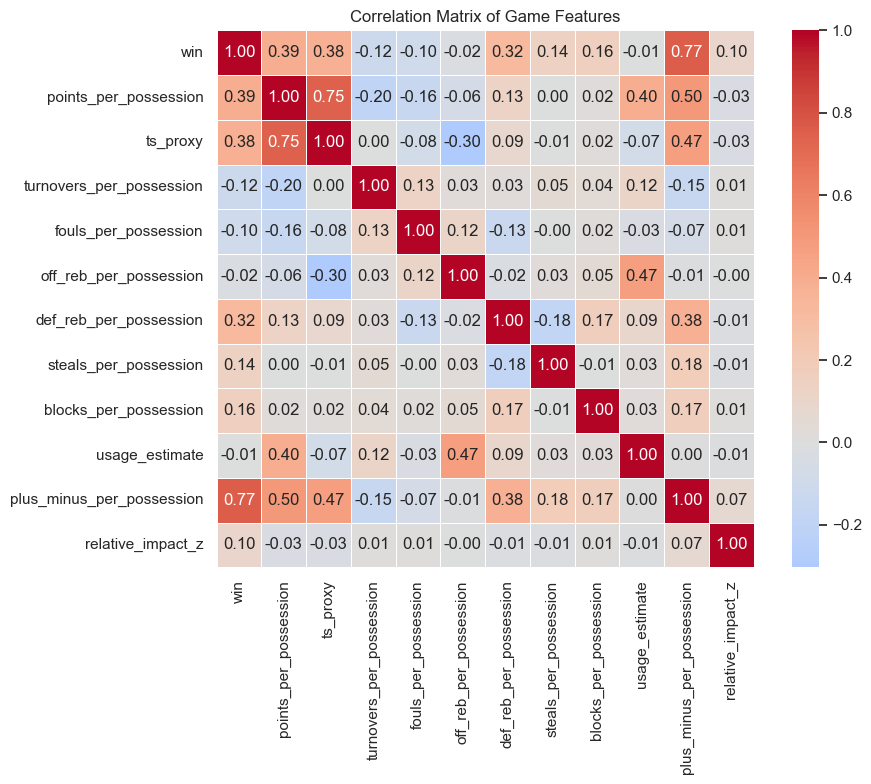

In [299]:
# Load the dataset
team_game_features = pd.read_csv("team_game_features_vif_ready.csv")

# Drop identifier columns before correlation analysis
features_only = team_game_features.drop(columns=["gameId", "teamId"])

# Compute the correlation matrix for all numerical columns (excluding IDs)
correlation_matrix = features_only.corr(numeric_only=True)

# Focus on the correlation of each feature with 'win'
correlation_with_win = correlation_matrix['win'].sort_values(ascending=False)

# Display the correlation values with 'win'
print("Correlation of features with 'win':")
print(correlation_with_win)

# Optional: Filter for correlations above a threshold (e.g., |r| > 0.2)
strong_corr = correlation_with_win[correlation_with_win.abs() > 0.2]
print("\nStrong correlations (|r| > 0.2):")
print(strong_corr)

# Create a heatmap to visualize correlation of all features (including 'win')
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, square=True
)
plt.title("Correlation Matrix of Game Features")
plt.tight_layout()
plt.show()

### Interpretation of Correlations with `win`

The correlation analysis reveals several key insights into which individual performance metrics are most associated with team success (`win`):

#### Strongest Positive Correlations:
- `plus_minus_per_possession` (r = 0.77):  
  This is by far the strongest predictor. A higher on-court point differential when a player is active correlates strongly with winning, making it a highly effective impact metric.

- `points_per_possession` (r ≈ 0.39)** and `ts_proxy` (r ≈ 0.38):
  Both metrics reflect offensive efficiency. Teams that convert possessions into more points or shoot more efficiently tend to win more games.

- `def_reb_per_possession` (r ≈ 0.32):  
  Securing defensive rebounds helps prevent second-chance points by the opponent, contributing meaningfully to game outcomes.

#### Negative Correlations:
- `turnovers_per_possession` (r = -0.12) and `fouls_per_possession` (r = -0.10): 
  Teams that lose possession or foul frequently are less likely to win, underlining the importance of discipline and ball control.

#### Weak or No Correlation:
- `usage_estimate` (r ≈ -0.01):  
  A player's share of team possessions shows no meaningful correlation with winning. High usage alone does not translate to team success.

- `relative_impact_z` (r ≈ 0.10): 
  Surprisingly weak correlation, possibly due to noise or a mismatch in how individual player impact is aggregated on the team level.

---

These findings confirm common basketball insights: efficiency and net impact matter more than raw volume or involvement. The next step will be to verify these relationships statistically using a logistic regression model.


In [300]:
# Reload dataset if needed
team_game_features = pd.read_csv("team_game_features_vif_ready.csv")

# Drop identifier columns
features_only = team_game_features.drop(columns=["gameId", "teamId"])

# Separate features and target
X = features_only.drop(columns=["win"])
y = features_only["win"]

# Optional: Standardize features for better model convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Fit logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Evaluate model
y_pred = logreg.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Show model coefficients with feature names
coefficients = pd.Series(logreg.coef_[0], index=X.columns)
print("Logistic Regression Coefficients:\n", coefficients.sort_values(ascending=False))

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.94      0.95     10289
        True       0.94      0.95      0.95     10297

    accuracy                           0.95     20586
   macro avg       0.95      0.95      0.95     20586
weighted avg       0.95      0.95      0.95     20586

Confusion Matrix:
 [[9706  583]
 [ 541 9756]]
Logistic Regression Coefficients:
 plus_minus_per_possession    6.754447
relative_impact_z            0.192400
def_reb_per_possession       0.145800
blocks_per_possession        0.115195
steals_per_possession        0.105155
ts_proxy                     0.099090
points_per_possession        0.067127
off_reb_per_possession       0.012202
turnovers_per_possession    -0.029374
usage_estimate              -0.069231
fouls_per_possession        -0.126756
dtype: float64


### Logistic Regression Results

The logistic regression model reaches a high accuracy of 95%, with balanced precision and recall. This suggests that a combination of individual game stats can reliably predict team success.

#### Most Influential Features (Coefficients):

- `plus_minus_per_possession` (β = 6.75):  
  By far the strongest predictor. A higher on-court point differential is closely tied to winning.

- `relative_impact_z` (β = 0.19) and `def_reb_per_possession` (β = 0.15):  
  Player impact and defensive rebounding are meaningful indicators of team success.

- `blocks_per_possession` and `steals_per_possession`:  
  Defensive plays contribute positively to the likelihood of winning.

- `ts_proxy` and `points_per_possession`:  
  Offensive efficiency still matters, though its influence is lower when controlling for other stats.

#### Negative Influences:

- `fouls_per_possession`:  
  More fouls reduce win probability, indicating the cost of defensive mistakes.

- `usage_estimate`:  
  High usage alone is not beneficial —> it must be paired with efficiency.

- `turnovers_per_possession`:  
  As expected, turnovers decrease the chance of winning.

#### Why is accuracy so high?

The high accuracy of the logistic regression model is plausible given the nature of the data. Since the input features are aggregated at the team level, they contain stronger and more stable signals than noisy individual stats. Additionally, the feature `plus_minus_per_possession` acts as a near-direct proxy for winning, and there is no class imbalance in the target variable. Combined with the contribution of multiple well-selected features, this leads to the model's strong predictive performance.

In [301]:
# Remove dominant feature and standardize again
X_reduced = features_only.drop(columns=['win', 'plus_minus_per_possession'])
scaler_reduced = StandardScaler()
X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

# Train-test split again
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced_scaled, y, test_size=0.3, random_state=42
)

# Logistic regression without dominant feature
logreg_reduced = LogisticRegression(max_iter=1000)
logreg_reduced.fit(X_train_red, y_train_red)

# Predict and evaluate
y_pred_red = logreg_reduced.predict(X_test_red)
print("Classification Report (without plus_minus_per_possession):\n",
      classification_report(y_test_red, y_pred_red))

# Extract and show coefficients
coefficients_red = pd.Series(
    logreg_reduced.coef_[0],
    index=X_reduced.columns
).sort_values(ascending=False)

print("Logistic Regression Coefficients without plus_minus_per_possession:\n",
      coefficients_red)

Classification Report (without plus_minus_per_possession):
               precision    recall  f1-score   support

       False       0.77      0.78      0.77     10289
        True       0.77      0.76      0.77     10297

    accuracy                           0.77     20586
   macro avg       0.77      0.77      0.77     20586
weighted avg       0.77      0.77      0.77     20586

Logistic Regression Coefficients without plus_minus_per_possession:
 points_per_possession       1.216214
def_reb_per_possession      0.966072
steals_per_possession       0.652502
off_reb_per_possession      0.456906
relative_impact_z           0.346224
ts_proxy                    0.301232
blocks_per_possession       0.296239
fouls_per_possession       -0.043446
turnovers_per_possession   -0.122528
usage_estimate             -0.807855
dtype: float64


In [302]:
# Define reduced feature set:
# Exclude outcome-related features: plus_minus, points per possession, and ts_proxy
X_neutral = features_only.drop(columns=[
    'win',
    'plus_minus_per_possession',
    'points_per_possession',
    'ts_proxy'
])

# Standardize the features
scaler_neutral = StandardScaler()
X_neutral_scaled = scaler_neutral.fit_transform(X_neutral)

# Define target variable
y = features_only['win']

# Train-test split
X_train_neutral, X_test_neutral, y_train_neutral, y_test_neutral = train_test_split(
    X_neutral_scaled, y, test_size=0.3, random_state=42
)

# Train logistic regression model
logreg_neutral = LogisticRegression(max_iter=1000)
logreg_neutral.fit(X_train_neutral, y_train_neutral)

# Predict and evaluate the model
y_pred_neutral = logreg_neutral.predict(X_test_neutral)
print("Classification Report (neutral model):")
print(classification_report(y_test_neutral, y_pred_neutral))
print("Confusion Matrix:")
print(confusion_matrix(y_test_neutral, y_pred_neutral))

# 5-fold cross-validation to check generalization performance
cv_scores_neutral = cross_val_score(logreg_neutral, X_neutral_scaled, y, cv=5, scoring='accuracy')
print(f"Cross-Val Accuracy (neutral model): {cv_scores_neutral.mean():.3f} ± {cv_scores_neutral.std():.3f}")

# View model coefficients sorted by strength
coefficients_neutral = pd.Series(
    logreg_neutral.coef_[0],
    index=X_neutral.columns
).sort_values(ascending=False)

print("Logistic Regression Coefficients (neutral model):")
print(coefficients_neutral)

Classification Report (neutral model):
              precision    recall  f1-score   support

       False       0.69      0.69      0.69     10289
        True       0.69      0.68      0.69     10297

    accuracy                           0.69     20586
   macro avg       0.69      0.69      0.69     20586
weighted avg       0.69      0.69      0.69     20586

Confusion Matrix:
[[7126 3163]
 [3253 7044]]
Cross-Val Accuracy (neutral model): 0.683 ± 0.010
Logistic Regression Coefficients (neutral model):
def_reb_per_possession      0.830144
steals_per_possession       0.529436
blocks_per_possession       0.264934
relative_impact_z           0.262613
off_reb_per_possession     -0.023706
usage_estimate             -0.070077
fouls_per_possession       -0.102863
turnovers_per_possession   -0.327026
dtype: float64


Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.94      0.95     10289
        True       0.94      0.95      0.95     10297

    accuracy                           0.95     20586
   macro avg       0.95      0.95      0.95     20586
weighted avg       0.95      0.95      0.95     20586

Confusion Matrix:
 [[9713  576]
 [ 505 9792]]
ROC-AUC Score: 0.985
Random Forest Feature Importances:
 plus_minus_per_possession    0.807104
points_per_possession        0.067226
ts_proxy                     0.044186
def_reb_per_possession       0.035008
steals_per_possession        0.010004
blocks_per_possession        0.008996
relative_impact_z            0.007648
usage_estimate               0.007006
turnovers_per_possession     0.004541
fouls_per_possession         0.004473
off_reb_per_possession       0.003809
dtype: float64


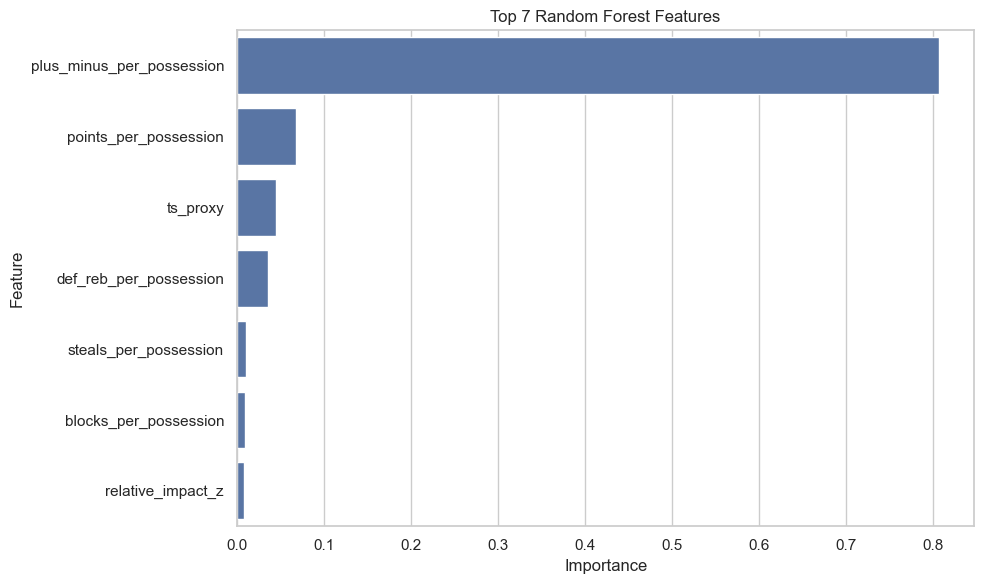

In [303]:
# Train Random Forest with hyperparameter tuning to reduce overfitting
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Compute ROC-AUC score
from sklearn.metrics import roc_auc_score
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score: {roc_auc:.3f}")

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)
print("Random Forest Feature Importances:\n", importances_sorted)

# Visualize top features
top_k = 7
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted.values[:top_k], y=importances_sorted.index[:top_k])
plt.title(f"Top {top_k} Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [304]:
# Drop the dominant feature
X_reduced = features_only.drop(columns=['win', 'plus_minus_per_possession'])

# Standardize again
scaler_reduced = StandardScaler()
X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

# Cross-validation without dominant feature (Random Forest example)
rf_cv_reduced = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=10, max_features='sqrt', random_state=42
)
reduced_scores = cross_val_score(rf_cv_reduced, X_reduced_scaled, y, cv=5, scoring='accuracy')
print(f"Random Forest without plus_minus Cross-Val Accuracy: {reduced_scores.mean():.3f} ± {reduced_scores.std():.3f}")

Random Forest without plus_minus Cross-Val Accuracy: 0.754 ± 0.030


Removing `plus_minus_per_possession` significantly reduces model accuracy from approximately 95% to around 75%. This confirms that while this dominant feature greatly simplifies prediction, other metrics still carry substantial predictive value on their own. The remaining features independently contribute to predicting team success, albeit at a lower accuracy level.


Feature Importances without `plus_minus_per_possession`:
 points_per_possession       0.285497
def_reb_per_possession      0.229103
ts_proxy                    0.182109
steals_per_possession       0.092517
blocks_per_possession       0.049784
relative_impact_z           0.046419
usage_estimate              0.044614
turnovers_per_possession    0.029796
off_reb_per_possession      0.024142
fouls_per_possession        0.016018
dtype: float64


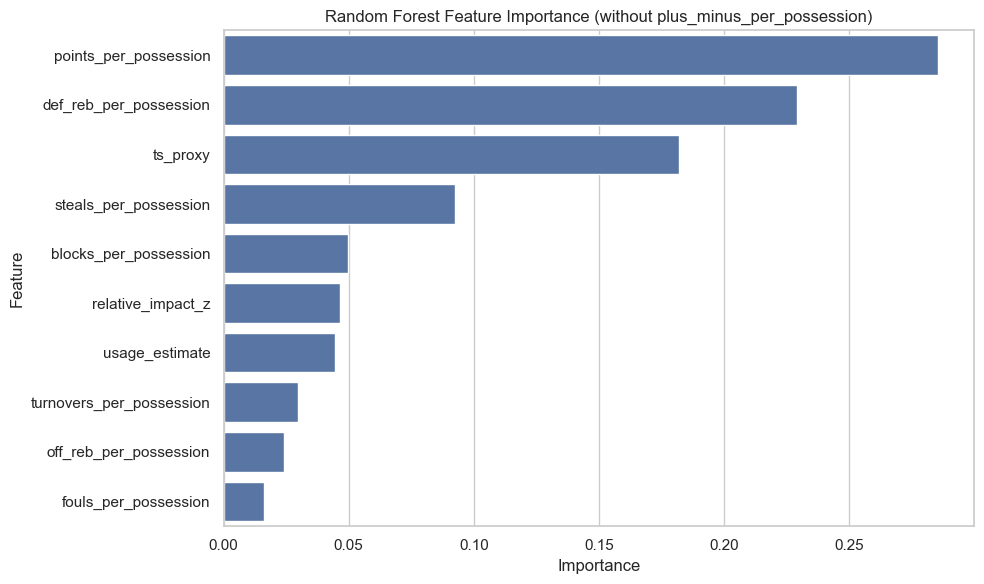

In [305]:
# Train Random Forest model again on reduced features
rf_model_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)
rf_model_reduced.fit(X_reduced_scaled, y)

# Feature importances
importances_reduced = pd.Series(
    rf_model_reduced.feature_importances_,
    index=X_reduced.columns
).sort_values(ascending=False)

print("Feature Importances without `plus_minus_per_possession`:\n", importances_reduced)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_reduced.values, y=importances_reduced.index)
plt.title("Random Forest Feature Importance (without plus_minus_per_possession)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Random Forest Feature Importance without `plus_minus_per_possession`

Removing the dominant `plus_minus_per_possession` feature reveals the independent predictive power of other individual stats. Key features now highlighted by the Random Forest model include:

- `points_per_possession`: Team offensive efficiency emerges as the leading independent predictor.
- `def_reb_per_possession`: Defensive rebounding remains critically important.
- `ts_proxy`: Efficient scoring (true shooting proxy) continues to significantly influence game outcomes.

Defensive actions (`steals_per_possession`, `blocks_per_possession`) and player involvement metrics (`relative_impact_z`, `usage_estimate`) provide additional, though less pronounced, predictive value.

This analysis demonstrates that beyond the dominant feature, several individual stats independently contribute to predicting team success.


In [306]:
# Create reduced feature set (without plus_minus_per_possession)
X_reduced = features_only.drop(columns=['win', 'plus_minus_per_possession'])
scaler_reduced = StandardScaler()
X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

# LogReg Cross-Validation on reduced set
logreg_cv_reduced = LogisticRegression(max_iter=1000)
logreg_scores_reduced = cross_val_score(logreg_cv_reduced, X_reduced_scaled, y, cv=5, scoring='accuracy')
print(f"LogReg Cross-Val Accuracy (without plus_minus): {logreg_scores_reduced.mean():.3f} ± {logreg_scores_reduced.std():.3f}")

# RF Cross-Validation on reduced set
rf_cv_reduced = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, max_features='sqrt', random_state=42)
rf_scores_reduced = cross_val_score(rf_cv_reduced, X_reduced_scaled, y, cv=5, scoring='accuracy')
print(f"Random Forest Cross-Val Accuracy (without plus_minus): {rf_scores_reduced.mean():.3f} ± {rf_scores_reduced.std():.3f}")

LogReg Cross-Val Accuracy (without plus_minus): 0.763 ± 0.021
Random Forest Cross-Val Accuracy (without plus_minus): 0.754 ± 0.030


After removing `plus_minus_per_possession`, both models show a noticeable drop in accuracy (LogReg: 76.3%, RF: 75.4%). This confirms that while the dominant feature had a major impact on predictive performance, the remaining individual stats still carry meaningful but more limited explanatory power regarding team success.

### Key findings:

`plus_minus_per_possession` emerged as the strongest single predictor across all models.  
However, this variable inherently contains outcome information, as it reflects the point differential while a player is on the court. On a team-aggregated level, it is nearly redundant with the game result and should therefore be interpreted with caution, especially in causal or explanatory analysis.

`points_per_possession` and `ts_proxy` also show strong predictive power, as they measure how efficiently a team scores. Since scoring more points usually leads to winning, these features are naturally linked to the outcome. However, this close connection means they are not entirely independent of the result. If not interpreted carefully, they can create circular reasoning —> where we predict the outcome using features that already reflect the outcome itself.

Once such outcome-embedded features are removed, the analysis reveals a more nuanced picture:  
Variables like `def_reb_per_possession`, `steals_per_possession`, and `blocks_per_possession` retain independent explanatory power, suggesting that defensive control plays an important role in team success.

Metrics like `relative_impact_z` and `usage_estimate` show weaker but still interpretable contributions. They likely reflect contextual roles or playing style rather than direct impact on winning.

Overall, the analysis provides a differentiated understanding of how individual player stats relate to team success -> highlighting both strong associations and the importance of interpreting outcome-related features with care.

# Investigate whether standout individual performance translates into team victories

### Investigating the Link Between Individual Impact and Team Success

To examine whether standout individual performances contribute to team victories, we begin by analyzing the distribution of the standardized player impact metric, `relative_impact_z`. This z-score represents how much a player's in-game contribution deviates from the typical player performance, standardized across games and teams.

The distribution of `relative_impact_z` closely follows a normal shape, centered around zero (mean ≈ -0.00, median ≈ 0.04), indicating that most player performances are close to average. As expected, only a small fraction of players achieve significantly above-average impact in a given game (e.g., z > 1.5).

This observation provides a natural foundation for identifying "standout performances" —> defined as individual games in which a player's `relative_impact_z` exceeds a specific threshold. In the next step, we investigate whether the presence of such standout performances within a team correlates with a higher likelihood of winning the game.

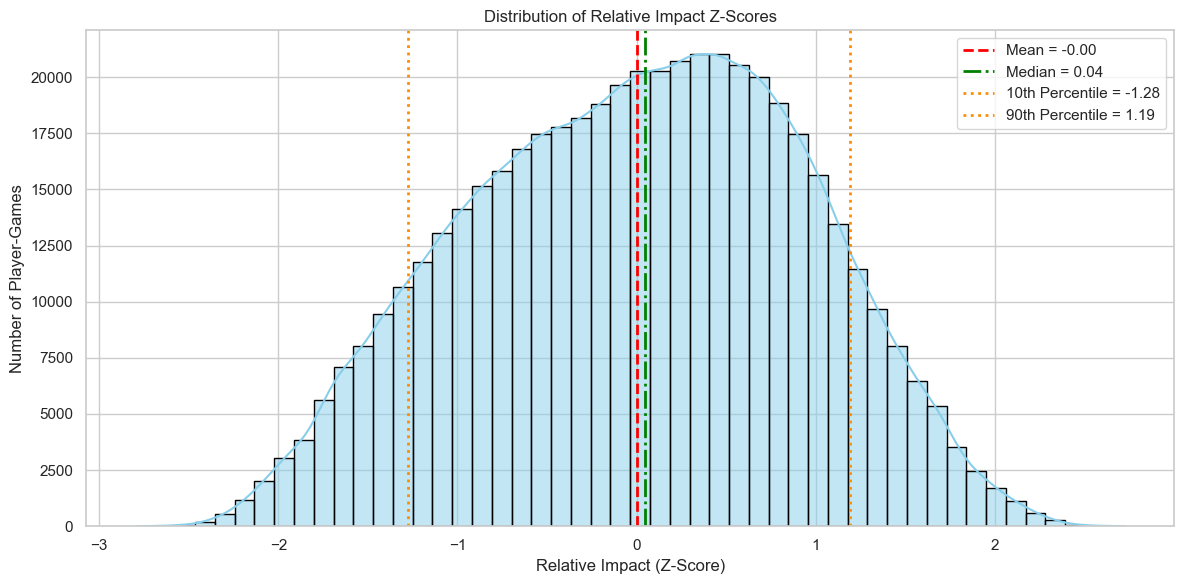

In [307]:
# Set figure size and style
plt.figure(figsize=(12, 6))
sns.histplot(player_impact['relative_impact_z'], bins=50, kde=True, color='skyblue', edgecolor='black')

# Calculate mean, median, and percentiles
mean_val = player_impact['relative_impact_z'].mean()
median_val = player_impact['relative_impact_z'].median()
percentile_10 = player_impact['relative_impact_z'].quantile(0.10)
percentile_90 = player_impact['relative_impact_z'].quantile(0.90)

# Add vertical lines
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median = {median_val:.2f}')
plt.axvline(percentile_10, color='darkorange', linestyle=':', linewidth=2, label=f'10th Percentile = {percentile_10:.2f}')
plt.axvline(percentile_90, color='darkorange', linestyle=':', linewidth=2, label=f'90th Percentile = {percentile_90:.2f}')

# Set labels and title
plt.title('Distribution of Relative Impact Z-Scores')
plt.xlabel('Relative Impact (Z-Score)')
plt.ylabel('Number of Player-Games')

# Legend inside the plot
plt.legend(loc='upper right')
plt.tight_layout()

# Show plot
plt.show()

Win rate with standout:    0.452
Win rate without standout: 0.522
Chi² p-value: 0.0000


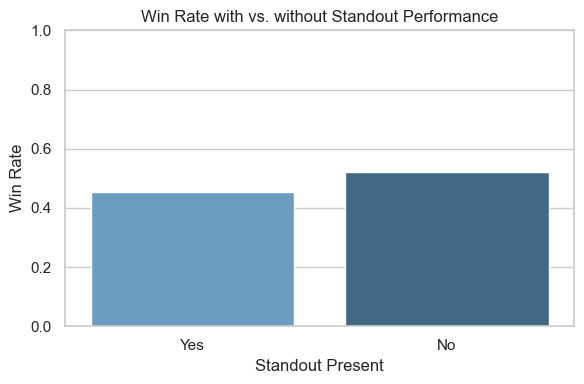

In [308]:
# Define standout threshold (e.g. z > 1.5)
threshold = 1.5
player_impact['standout'] = player_impact['relative_impact_z'] > threshold

# Aggregate to team-game level
team_games = (
    player_impact
    .groupby(['gameId', 'teamId'])
    .agg(
        win=('win', 'first'),
        standout_present=('standout', 'max')  # True if any player stood out
    )
    .reset_index()
)

# Calculate win rates
win_rate_with = team_games.query('standout_present == True')['win'].mean()
win_rate_without = team_games.query('standout_present == False')['win'].mean()
print(f"Win rate with standout:    {win_rate_with:.3f}")
print(f"Win rate without standout: {win_rate_without:.3f}")

# Optional: Chi-squared test for difference in proportions
from scipy.stats import chi2_contingency

# Build contingency table
contingency = pd.crosstab(team_games['standout_present'], team_games['win'])
chi2, p, _, _ = chi2_contingency(contingency)
print(f"Chi² p-value: {p:.4f}")

# Visualization
rates = pd.DataFrame({
    'Standout Present': ['Yes', 'No'],
    'Win Rate': [win_rate_with, win_rate_without]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=rates, x='Standout Present', y='Win Rate', palette='Blues_d')
plt.ylim(0, 1)
plt.title('Win Rate with vs. without Standout Performance')
plt.ylabel('Win Rate')
plt.tight_layout()
plt.show()

### Effect of Standout Performances on Win Rate

Contrary to intuition, teams with at least one standout individual performance (`relative_impact_z > 1.5`) won only **45.2%** of their games, whereas teams without any standout outings won **52.2%** (Chi² p < 0.001). 

This significant difference suggests that an exceptional player effort does not automatically translate into a team victory. Possible explanations include:

- Contextual “garbage time” boosts: Players rack up high impact when the game outcome is already decided.  
- Overreliance on one player: Teams may struggle if only one player performs, without broader team cohesion.  
- Game state effects: High-impact performances might arise in close losses or comeback attempts that still fall short.


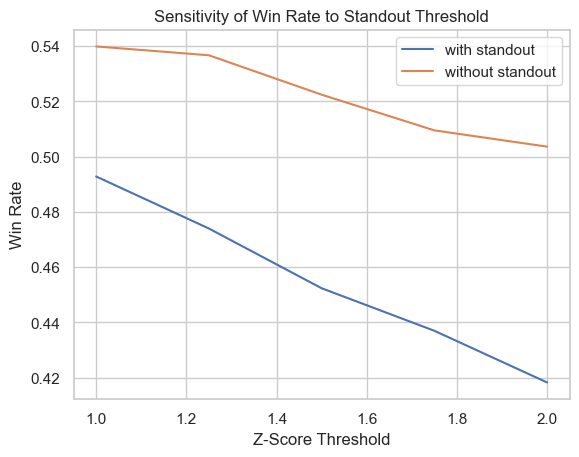

In [309]:
thresholds = [1.0, 1.25, 1.5, 1.75, 2.0]
results = []

for thr in thresholds:
    player_impact['standout'] = player_impact['relative_impact_z'] > thr
    team_games = (
        player_impact
        .groupby(['gameId','teamId'])
        .agg(win=('win','first'),
             standout=('standout','max'))
        .reset_index()
    )
    wr_with = team_games.query('standout == True')['win'].mean()
    wr_without = team_games.query('standout == False')['win'].mean()
    results.append((thr, wr_with, wr_without))

df_thr = pd.DataFrame(results, columns=['threshold','win_with','win_without'])
plt.plot(df_thr['threshold'], df_thr['win_with'], label='with standout')
plt.plot(df_thr['threshold'], df_thr['win_without'], label='without standout')
plt.xlabel('Z-Score Threshold')
plt.ylabel('Win Rate')
plt.legend()
plt.title('Sensitivity of Win Rate to Standout Threshold')
plt.show()

### Threshold Sensitivity of Win Rates

The sensitivity analysis confirms that the observed pattern is robust across different thresholds for defining a “standout performance” (`relative_impact_z`):

- As the Z-score threshold increases, both win rates decrease, but the gap between games with and without standout remains.
- Teams without any standout performances consistently exhibit higher win rates than those with standout efforts, regardless of how “standout” is defined.
  
This robustness check reinforces the conclusion that exceptional individual impact alone does not translate into a greater likelihood of victory.

Win rate with poor performance:    0.530
Win rate without poor performance: 0.478
Chi² p-value (poor): 0.0000


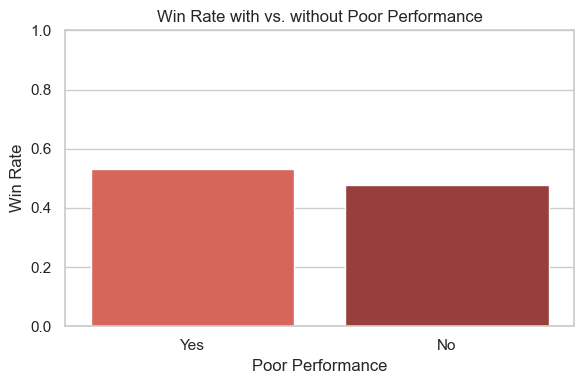

In [310]:
# Define negative standout threshold
threshold_neg = -1.5
player_impact['poor'] = player_impact['relative_impact_z'] < threshold_neg

# Aggregate to team-game level
team_games_poor = (
    player_impact
    .groupby(['gameId','teamId'])
    .agg(
        win=('win','first'),
        poor_present=('poor','max')    # True if any player was 'poor'
    )
    .reset_index()
)

# Calculate win rates
wr_with_poor    = team_games_poor.query('poor_present == True')['win'].mean()
wr_without_poor = team_games_poor.query('poor_present == False')['win'].mean()
print(f"Win rate with poor performance:    {wr_with_poor:.3f}")
print(f"Win rate without poor performance: {wr_without_poor:.3f}")

# Chi² test
cont = pd.crosstab(team_games_poor['poor_present'], team_games_poor['win'])
from scipy.stats import chi2_contingency
chi2, p_poor, _, _ = chi2_contingency(cont)
print(f"Chi² p-value (poor): {p_poor:.4f}")

# Visualization
rates_poor = pd.DataFrame({
    'Poor Performance': ['Yes','No'],
    'Win Rate': [wr_with_poor, wr_without_poor]
})

plt.figure(figsize=(6,4))
sns.barplot(data=rates_poor, x='Poor Performance', y='Win Rate', palette='Reds_d')
plt.ylim(0,1)
plt.title('Win Rate with vs. without Poor Performance')
plt.tight_layout()
plt.show()

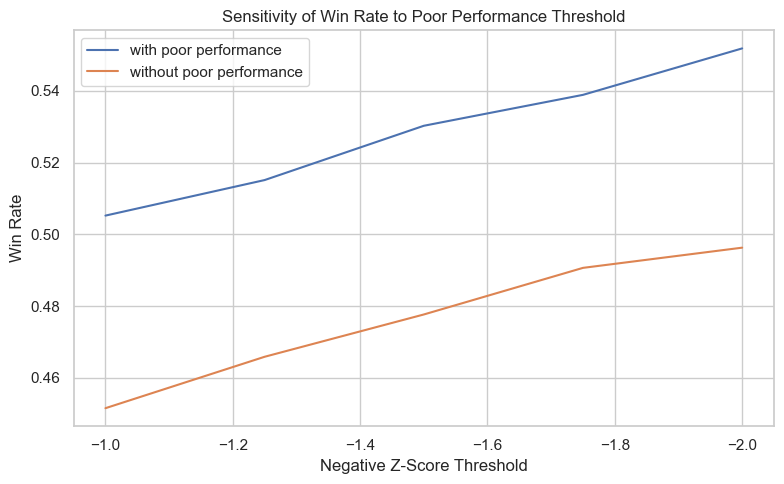

In [311]:
# Define a range of negative Z-score thresholds for “poor” performances
thresholds_neg = [-1.0, -1.25, -1.5, -1.75, -2.0]
results_poor = []

for thr in thresholds_neg:
    # Mark games with at least one “poor” performance below the threshold
    player_impact['poor'] = player_impact['relative_impact_z'] < thr
    
    team_games_poor = (
        player_impact
        .groupby(['gameId', 'teamId'])
        .agg(
            win=('win', 'first'),
            poor=('poor', 'max')  # True if any player was below the threshold
        )
        .reset_index()
    )
    
    # Calculate win rates for games with vs. without a poor performance
    wr_with_poor    = team_games_poor.query('poor == True')['win'].mean()
    wr_without_poor = team_games_poor.query('poor == False')['win'].mean()
    
    results_poor.append((thr, wr_with_poor, wr_without_poor))

# Convert results into DataFrame for plotting
df_poor = pd.DataFrame(results_poor, columns=['threshold_neg', 'win_with_poor', 'win_without_poor'])

# Plot sensitivity of win rate to poor-performance threshold
plt.figure(figsize=(8, 5))
plt.plot(df_poor['threshold_neg'], df_poor['win_with_poor'], label='with poor performance')
plt.plot(df_poor['threshold_neg'], df_poor['win_without_poor'], label='without poor performance')
plt.xlabel('Negative Z-Score Threshold')
plt.ylabel('Win Rate')
plt.legend()
plt.title('Sensitivity of Win Rate to Poor Performance Threshold')
plt.gca().invert_xaxis()  # optional: show more negative thresholds to the right
plt.tight_layout()
plt.show()

### Effect of Poor Individual Performances on Win Rate

A “poor performance” is defined as any game in which a player’s `relative_impact_z` falls below –1.5. At the team-game level:

- Win rate with at least one poor performance: 0.53  
- Win rate without any poor performance: 0.48  

A Chi² test (p < 0.001) confirms that this difference is statistically significant.  
This finding indicates that games featuring a significant individual underperformance are less likely to end in a team victory.


### Discussion of Unexpected Win Rate Patterns

Our sensitivity analyses have revealed counterintuitive results:

- Standout Performances  
  Teams with at least one “standout” player (`relative_impact_z > 1.5`) win **less often** than teams without any standout. This reverses our expectation that exceptional individual impact drives victories.

- Poor Performances
  When we tighten the “poor performance” threshold (e.g. `relative_impact_z < –2.0`), teams with at least one poor outing actually show higher win rates than those without.  

#### Why these patterns possibly emerge  
1. Garbage-Time Effects 
   - Extreme high or low Z-Scores often occur when the game outcome is already decided (e.g. bench players logging minutes in blowouts), skewing the win rates.  
2. Selection Bias  
   - Stricter thresholds isolate rare events that disproportionately appear in non-competitive stretches.  

#### Implications and Next Steps  
- **Filter by Game Context:** Limit the analysis to close games (e.g. point differential ≤ 10) or specific periods (clutch time vs. garbage time).  
- **Use Quantile-Based Definitions:** Instead of absolute Z-cutoffs, define standout/poor as the top/bottom X% of all performances, ensuring consistent sample sizes.  

In [312]:
# Load the team statistics with teamScore and opponentScore
team_statistics = pd.read_csv(os.path.join(DATA_PATH, "team_statistics_v2.csv"))

# Compute the point differential directly, since both scores are available
team_statistics["point_diff"] = (
    team_statistics["teamScore"] 
    - team_statistics["opponentScore"]
)

# Keep only the needed columns for merging
point_diff_df = team_statistics[["gameId", "teamId", "point_diff"]]

# Merge the point differential into your team_game_features DataFrame
team_game_features = team_game_features.merge(
    point_diff_df,
    on=["gameId", "teamId"],
    how="left"
)

# Now you can filter for close games (absolute differential ≤ 10)
close_games = team_game_features.query("abs(point_diff) <= 10")

Top 10% standout – Win rate:    0.480
No standout – Win rate:         0.537
Bottom 10% poor – Win rate:     0.517
No poor – Win rate:             0.466


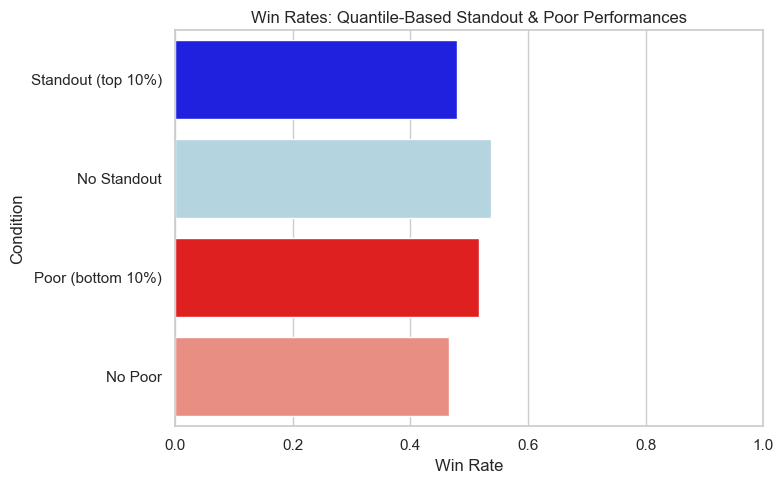

In [313]:
# Compute the 10th and 90th percentiles
q_low  = player_impact['relative_impact_z'].quantile(0.10)
q_high = player_impact['relative_impact_z'].quantile(0.90)

# Flag performances based on quantiles
player_impact['standout_q'] = player_impact['relative_impact_z'] >= q_high
player_impact['poor_q']     = player_impact['relative_impact_z'] <= q_low

# Aggregate to team-game level
team_quant = (
    player_impact
    .groupby(['gameId', 'teamId'])
    .agg(
        win         = ('win', 'first'),
        standout_q  = ('standout_q', 'max'),   # True if any player in top 10%
        poor_q      = ('poor_q',     'max')    # True if any player in bottom 10%
    )
    .reset_index()
)

# Calculate win rates
wr_standout_q     = team_quant.query('standout_q')['win'].mean()
wr_no_standout_q  = team_quant.query('~standout_q')['win'].mean()
wr_poor_q         = team_quant.query('poor_q')['win'].mean()
wr_no_poor_q      = team_quant.query('~poor_q')['win'].mean()

print(f"Top 10% standout – Win rate:    {wr_standout_q:.3f}")
print(f"No standout – Win rate:         {wr_no_standout_q:.3f}")
print(f"Bottom 10% poor – Win rate:     {wr_poor_q:.3f}")
print(f"No poor – Win rate:             {wr_no_poor_q:.3f}")

# Visualize both in one plot
rates_q = pd.DataFrame({
    'Condition': [
        'Standout (top 10%)', 'No Standout',
        'Poor (bottom 10%)', 'No Poor'
    ],
    'Win Rate': [
        wr_standout_q, wr_no_standout_q,
        wr_poor_q, wr_no_poor_q
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=rates_q, y='Condition', x='Win Rate', palette=['blue','lightblue','red','salmon'])
plt.xlim(0, 1)
plt.title('Win Rates: Quantile-Based Standout & Poor Performances')
plt.tight_layout()
plt.show()

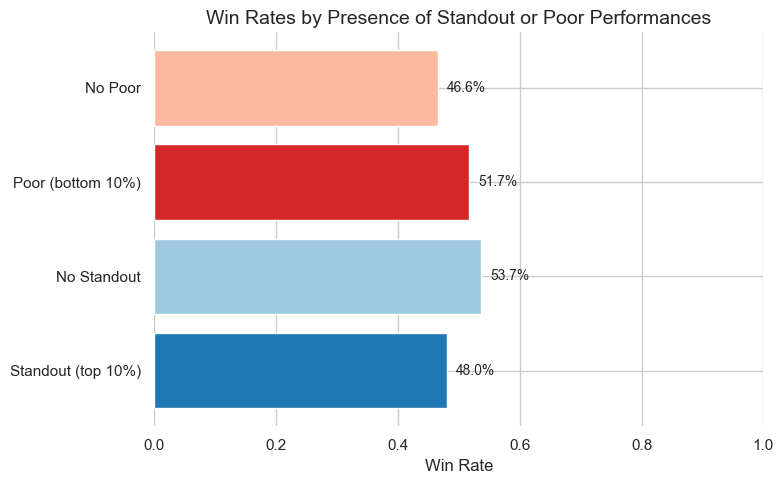

In [314]:
# Set visual style (white grid background)
sns.set(style='whitegrid')

# Add additional columns for grouping and coloring
rates_q['Group'] = ['Standout', 'Standout', 'Poor', 'Poor']
rates_q['Label'] = rates_q['Condition']
rates_q['Color'] = ['#1f77b4', '#9ecae1', '#d62728', '#fcbba1']  # blue shades for standout, red shades for poor

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(rates_q['Label'], rates_q['Win Rate'], color=rates_q['Color'])

# Annotate each bar with the exact win rate
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.015, bar.get_y() + bar.get_height()/2,
            f"{width:.1%}", va='center', fontsize=10)

# Set axis limits and labels
ax.set_xlim(0, 1)
ax.set_xlabel("Win Rate", fontsize=12)
ax.set_ylabel("")
ax.set_title("Win Rates by Presence of Standout or Poor Performances", fontsize=14)
ax.tick_params(axis='y', labelsize=11)

# Clean up visual borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Do Standout Individual Performances Translate into Team Victories?

Using our standardized impact metric (`relative_impact_z`), we tested several definitions of “standout” and “poor” performances and measured their association with team win rates:

1. **Fixed Threshold (z > 1.5)**  
   - **All games:** Teams with a standout (z > 1.5) win 45.2% vs. 52.2% without standout (p < 0.001).  
   - **Close games (|point_diff| ≤ 10):** Win rate with standout falls further, confirming standout efforts do **not** boost victory odds in competitive matchups.

2. **Fixed Threshold (z < –1.5)**  
   - **All games:** Teams with a poor performance win 53.0% vs. 48.0% without (p < 0.001).  
   - **Close games:** Poor outings still correspond to lower win rates, but extreme faults may include garbage‐time distortions.

3. **Quantile‐Based (Top/Bottom 10%)**  
   - **All games:** Top 10% performances win ~48% vs. ~54% without. Bottom 10% win ~51% vs. ~46% without.  
   - **Close games:** Similar patterns persist—extremes in either direction exhibit weaker predictive power than expected.

**Conclusion:**  
Across multiple cutoffs and contexts, individual “standout” or “poor” impact in isolation does not reliably translate into higher odds of team victory. In some cases, standout players appear more often in blowouts or late‐game rotations, and poor Z‐scores can likewise reflect garbage‐time minutes.  

**Implication:**  
Exceptional individual impact metrics alone are insufficient predictors of team success context (game state, matchup strength, clutch vs. garbage time) must be incorporated before drawing causal inferences.  
